# Trabajo de Fin de Grado: Desarrollo y Evaluación de un Método Cuántico de Selección de Características

## Notebook 02 - Fase 2: Preprocesado Estructural de los Datasets

Esta fase transforma los datos crudos solo cuando la transformación es estructural y verificable: normalización de nombres, exclusión de identificadores, codificación trazable del target, guardado y recarga de datasets procesados. Las transformaciones que aprenden parámetros de los predictores, como imputación, `OneHotEncoder` o escalado, no se ajustan aquí.

El anteproyecto del TFG fija cinco objetivos: revisión de métodos clásicos, selección de datasets de referencia, comparación clásica, desarrollo de QFS con bloqueo de Rydberg y comparación del método cuántico frente a los mejores clásicos. Fase 2 sostiene el segundo objetivo y protege los tres siguientes: el bloque clásico solo es una referencia válida si el preprocesado no introduce información del conjunto completo antes de los splits.

Los documentos QFS justifican por qué esta fase debe producir datos numéricamente trazables sin contaminar el experimento. PAPER_QFS y QFS_D2 formulan la relevancia como información mutua `I(x_i;y)`, la redundancia como `I(x_i;x_j)`, la geometría atómica mediante distancias/MDS y el objetivo `Q(x; alpha)` como equilibrio entre variables informativas y no redundantes. Por eso el bloque cuántico necesita targets codificados de forma estable, identificadores fuera de las predictoras y transformaciones estadísticas diferidas a estimadores ajustados solo con train.

Desde esta fase se deja explícito que `olive_oil` contiene dos formulaciones supervisadas posibles: `area` con 3 clases y `target` con 9 clases. Esa distinción evita tratar como una única tarea dos problemas de clasificación relacionados pero distintos.


## Importación de Librerías

Se importan las librerías necesarias para cargar datos, calcular métricas de preprocesado, generar figuras y mostrar tablas en el notebook.


In [1]:
from pathlib import Path
import io
import re
import shutil
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import Markdown, display

warnings.filterwarnings("ignore", category=FutureWarning)


## Definición de Rutas y Directorios de Salida

Se definen las rutas utilizadas durante la fase. Antes de generar nuevas salidas se limpian las tablas y figuras previas de Fase 2 para evitar que resultados antiguos aparezcan mezclados con la versión corregida del notebook.


In [2]:
# Rutas principales del proyecto.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW_DATA_DIR = PROJECT_ROOT / "data" / "01_raw"
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
PHASE1_TABLES_DIR = PROJECT_ROOT / "results" / "tables" / "01_raw_eda"
PHASE2_TABLES_DIR = PROJECT_ROOT / "results" / "tables" / "02_preprocessing"
PHASE2_FIGURES_DIR = PROJECT_ROOT / "results" / "figures" / "02_preprocessing"
PHASE2_REPORTS_DIR = PROJECT_ROOT / "results" / "reports" / "02_preprocessing"

for output_dir in [PROCESSED_DATA_DIR, PHASE2_TABLES_DIR, PHASE2_FIGURES_DIR, PHASE2_REPORTS_DIR]:
    output_dir.mkdir(parents=True, exist_ok=True)

for old_table_path in PHASE2_TABLES_DIR.glob("*.csv"):
    old_table_path.unlink()

for old_figure_path in list(PHASE2_FIGURES_DIR.rglob("*.png")) + list(PHASE2_FIGURES_DIR.rglob("*.pdf")):
    old_figure_path.unlink()

print(f"Proyecto: {PROJECT_ROOT}")
print(f"Datos crudos: {RAW_DATA_DIR.relative_to(PROJECT_ROOT)}")
print(f"Tablas de Fase 1: {PHASE1_TABLES_DIR.relative_to(PROJECT_ROOT)}")
print(f"Tablas de Fase 2: {PHASE2_TABLES_DIR.relative_to(PROJECT_ROOT)}")
print(f"Figuras de Fase 2: {PHASE2_FIGURES_DIR.relative_to(PROJECT_ROOT)}")


Proyecto: /home/gosacar/TFG - QFS Last Chance Claude
Datos crudos: data/01_raw
Tablas de Fase 1: results/tables/01_raw_eda
Tablas de Fase 2: results/tables/02_preprocessing
Figuras de Fase 2: results/figures/02_preprocessing


Las rutas quedan fijadas en 5 ubicaciones del proyecto: datos crudos, datos procesados, tablas de Fase 1, tablas de Fase 2 y figuras de Fase 2. La limpieza inicial afecta solo a resultados `fase2_*.csv`, `*.png` y `*.pdf` dentro de las carpetas de salida, por lo que no modifica los datasets de entrada ni los resultados de otras fases.


## Configuración Visual y Parámetros Generales

La configuración visual se mantiene estable para que las figuras se puedan comparar entre datasets. Los umbrales que aparecen en el notebook son constantes explícitas, no valores escondidos dentro de una función.

Los tres umbrales son **alertas exploratorias**, no reglas automáticas de borrado:

- `LOW_CARDINALITY_RATIO = 0.01` hereda el criterio usado en Fase 1 y es una versión más estricta que el `uniqueCut = 10%` que usa `caret::nearZeroVar` para diagnosticar predictores de varianza casi nula.
- `DOMINANT_MODE_RATIO = 0.98` sigue la misma idea de `nearZeroVar`: una variable puede ser problemática si combina pocos valores distintos con una frecuencia muy concentrada. Se usa 98% para marcar solo dominancias extremas.
- `HIGH_CORRELATION_THRESHOLD = 0.85` mantiene la referencia de Fase 1 para correlación de Spearman fuerte. Herramientas como `caret::findCorrelation` suelen usar `cutoff = 0.90`; aquí se conserva 0.85 para no cambiar el criterio entre fases.

Referencias metodológicas:

- `caret::nearZeroVar`: https://rdrr.io/cran/caret/man/nearZeroVar.html
- `caret::findCorrelation`: https://rdrr.io/cran/caret/man/findCorrelation.html
- Scikit-learn, *Common pitfalls and recommended practices* sobre *data leakage*: https://scikit-learn.org/stable/common_pitfalls.html


In [3]:
RANDOM_STATE = 42
# Umbrales de alerta, no reglas de eliminación automática.
LOW_CARDINALITY_RATIO = 0.01
DOMINANT_MODE_RATIO = 0.98
HIGH_CORRELATION_THRESHOLD = 0.85
OUTLIER_RATE_ALERT_THRESHOLD = 0.10

DATASET_ORDER = [
    "breast_cancer_wisconsin",
    "customer_churn",
    "madelon",
    "olive_oil",
]

DATASET_COLORS = {
    "breast_cancer_wisconsin": "#2F6F9F",
    "customer_churn": "#D9822B",
    "madelon": "#5E8C61",
    "olive_oil": "#7A6FA5",
}

CATEGORY_COLORS = [
    "#2F6F9F",
    "#D9822B",
    "#5E8C61",
    "#7A6FA5",
    "#B85C5C",
    "#6F6A60",
]

plt.rcParams.update({
    "figure.facecolor": "#FAF7F2",
    "axes.facecolor": "#FAF7F2",
    "axes.edgecolor": "#D8D0C4",
    "axes.labelcolor": "#2D2A26",
    "text.color": "#2D2A26",
    "xtick.color": "#2D2A26",
    "ytick.color": "#2D2A26",
    "grid.color": "#E6DED2",
    "font.size": 10,
})

pd.set_option("display.max_columns", 32)
pd.set_option("display.max_rows", 60)
pd.set_option("display.max_colwidth", 80)
pd.set_option("display.precision", 4)


## Utilidades Generales del Notebook

Estas funciones se reutilizan en varias secciones. Son funciones de soporte: guardan tablas, muestran vistas compactas, guardan figuras y aplican estilo visual básico.


In [4]:
DISPLAY_COLUMN_NAMES = {
    "abs_tamano_efecto": "Tamaño de efecto absoluto",
    "baja_cardinalidad_relativa": "Baja cardinalidad relativa",
    "categoria": "Categoría",
    "codigo": "Código",
    "columna_original": "Columna original",
    "columna_procesada": "Columna procesada",
    "columnas": "Columnas",
    "columnas_originales": "Columnas originales",
    "columnas_procesadas": "Columnas procesadas",
    "columnas_renombradas": "Columnas renombradas",
    "columnas_eliminadas": "Columnas eliminadas",
    "dataset": "Dataset",
    "delta_abs": "Diferencia absoluta",
    "delta_columnas": "Diferencia de columnas",
    "delta_filas": "Diferencia de filas",
    "delta_pares": "Diferencia de pares",
    "duplicados_exactos": "Duplicados exactos",
    "dtype_original": "Tipo original",
    "dtype_procesado": "Tipo procesado",
    "etiquetas_alternativas_en_predictoras": "Etiquetas alternativas en predictoras",
    "filas": "Filas",
    "filas_originales": "Filas originales",
    "filas_procesadas": "Filas procesadas",
    "filas_raw": "Filas crudas",
    "filas_processed": "Filas procesadas",
    "frecuencia_moda": "Frecuencia de la moda",
    "iqr": "IQR",
    "iqr_mediano": "IQR mediano",
    "limite_inferior": "Límite inferior",
    "limite_superior": "Límite superior",
    "maximo": "Máximo",
    "mean_delta_abs": "Diferencia absoluta de medias",
    "mean_processed": "Media procesada",
    "mean_raw": "Media cruda",
    "mediana": "Mediana",
    "minimo": "Mínimo",
    "moda_dominante_98": "Moda dominante al 98%",
    "n": "N",
    "n_outliers_iqr": "Outliers IQR",
    "nombre_tamano_efecto": "Medida de efecto",
    "nulos": "Nulos",
    "nulos_procesados": "Nulos procesados",
    "pares_spearman_ge_085_processed": "Pares Spearman >= 0.85 procesados",
    "pares_spearman_ge_085_raw": "Pares Spearman >= 0.85 crudos",
    "pct_duplicados_exactos": "Proporción de duplicados exactos",
    "pct_nulos": "Proporción de nulos",
    "pct_nulos_maximo": "Proporción máxima de nulos",
    "pct_outliers_iqr": "Proporción de outliers IQR",
    "pct_outliers_maxima": "Proporción máxima de outliers IQR",
    "pct_outliers_media": "Proporción media de outliers IQR",
    "pct_processed": "Proporción procesada",
    "pct_raw": "Proporción cruda",
    "p_valor": "p-valor",
    "p_valor_fdr": "p-valor FDR",
    "predictoras": "Predictoras",
    "predictoras_categoricas": "Predictoras categóricas",
    "predictoras_si_onehot": "Predictoras con one-hot",
    "predictoras_sin_onehot": "Predictoras sin one-hot",
    "problema": "Problema",
    "proporcion": "Proporción",
    "rango": "Rango",
    "rango_maximo": "Rango máximo",
    "rango_mediano": "Rango mediano",
    "ratio_unicidad_maximo": "Ratio máximo de unicidad",
    "ratio_valores_unicos": "Ratio de valores únicos",
    "ruta": "Ruta",
    "std_delta_abs": "Diferencia absoluta de desviaciones",
    "std_processed": "Desviación procesada",
    "std_raw": "Desviación cruda",
    "tamano_efecto": "Tamaño de efecto",
    "target": "Target",
    "target_clases": "Clases del target",
    "target_en_predictoras": "Target en predictoras",
    "target_maximo": "Código máximo del target",
    "target_minimo": "Código mínimo del target",
    "target_nulos": "Nulos del target",
    "target_presente": "Target presente",
    "target_total_variation": "Variación total del target",
    "test": "Contraste",
    "valores_negativos": "Valores negativos",
    "valores_unicos": "Valores únicos",
    "valor_original": "Valor original",
    "variable": "Variable",
    "variable_original": "Variable original",
    "variable_procesada": "Variable procesada",
    "variables": "Variables",
    "variables_numericas": "Variables numéricas",
}


def preparar_tabla_para_mostrar(tabla):
    return tabla.rename(columns={name: DISPLAY_COLUMN_NAMES.get(name, name) for name in tabla.columns})


def guardar_tabla(tabla, nombre_archivo):
    ruta_tabla = PHASE2_TABLES_DIR / nombre_archivo
    tabla.to_csv(ruta_tabla, index=False)
    return ruta_tabla


def mostrar_tabla(tabla, nombre=None, n=10):
    tabla_visible = preparar_tabla_para_mostrar(tabla)
    if nombre is not None:
        display(Markdown(f"**{nombre}** - se muestran las primeras {min(n, tabla_visible.shape[0])} filas de {tabla_visible.shape[0]}."))
    display(tabla_visible.head(n))


def guardar_figura(figura, nombre_archivo):
    ruta_png = PHASE2_FIGURES_DIR / Path(nombre_archivo).with_suffix(".png")
    ruta_pdf = ruta_png.with_suffix(".pdf")
    ruta_png.parent.mkdir(parents=True, exist_ok=True)
    figura.savefig(ruta_png, dpi=300, bbox_inches="tight")
    figura.savefig(ruta_pdf, bbox_inches="tight")
    return ruta_png


def aplicar_estilo_eje(eje, eje_rejilla="x"):
    eje.spines["top"].set_visible(False)
    eje.spines["right"].set_visible(False)
    eje.grid(axis=eje_rejilla, alpha=0.65)
    eje.set_axisbelow(True)


In [5]:
def leer_tabla_csv(directorio, nombre_archivo):
    ruta_tabla = directorio / nombre_archivo
    if not ruta_tabla.exists():
        raise FileNotFoundError(f"No existe la tabla: {ruta_tabla}")
    return pd.read_csv(ruta_tabla)


def obtener_info_texto(datos_dataset):
    salida_info = io.StringIO()
    datos_dataset.info(buf=salida_info)
    return salida_info.getvalue()


def etiqueta_dataset(nombre_dataset):
    return nombre_dataset.replace("_", " ").title()


def convertir_escalar_python(valor):
    return valor.item() if hasattr(valor, "item") else valor


## 2.1 Carga de Datasets Crudos

La fase comienza cargando los datasets crudos uno a uno mediante lectura CSV directa y comprobación del target esperado. Este capítulo parte de las conclusiones de la revisión exploratoria de Fase 1, que se consultan más adelante solo cuando ayudan a interpretar identificadores y variables de revisión.


In [6]:
dataset_paths = {
    "breast_cancer_wisconsin": RAW_DATA_DIR / "breast_cancer_wisconsin.csv",
    "customer_churn": RAW_DATA_DIR / "customer_churn.csv",
    "madelon": RAW_DATA_DIR / "madelon.csv",
    "olive_oil": RAW_DATA_DIR / "olive_oil.csv",
}

expected_targets = {
    "breast_cancer_wisconsin": "target",
    "customer_churn": "Churn",
    "madelon": "target",
    "olive_oil": "target",
}

for dataset_name, dataset_path in dataset_paths.items():
    print(f"{dataset_name}: {dataset_path.exists()} -> {dataset_path.relative_to(PROJECT_ROOT)}")


breast_cancer_wisconsin: True -> data/01_raw/breast_cancer_wisconsin.csv
customer_churn: True -> data/01_raw/customer_churn.csv
madelon: True -> data/01_raw/madelon.csv
olive_oil: True -> data/01_raw/olive_oil.csv


Los 4 archivos crudos existen en `data/01_raw`, con rutas resueltas antes de leer contenido. Esta comprobación separa fallos de I/O de errores analíticos: si una carga fallara después, no sería por ausencia del CSV sino por estructura interna del dataset.


In [7]:
def cargar_dataset(ruta_dataset):
    if not ruta_dataset.exists():
        raise FileNotFoundError(f"No se encuentra el archivo: {ruta_dataset}")
    return pd.read_csv(ruta_dataset)


def resumir_carga_dataset(nombre_dataset, datos_dataset):
    target_name = expected_targets[nombre_dataset]
    return {
        "dataset": nombre_dataset,
        "archivo": dataset_paths[nombre_dataset].name,
        "filas": datos_dataset.shape[0],
        "columnas": datos_dataset.shape[1],
        "target": target_name,
        "target_presente": target_name in datos_dataset.columns,
    }


### Carga de Datos: `breast_cancer_wisconsin`


In [8]:
breast_cancer_wisconsin = cargar_dataset(dataset_paths["breast_cancer_wisconsin"])
print(f"shape: {breast_cancer_wisconsin.shape}")
display(breast_cancer_wisconsin.head())
print(obtener_info_texto(breast_cancer_wisconsin))


shape: (569, 32)


,id,target,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave_points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.1184,0.2776,0.3001,0.1471,0.2419,0.0787,1.0950,0.9053,8.589,153.40,0.0064,0.0490,0.0537,0.0159,0.0300,0.0062,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.1189
1,842517,M,20.57,17.77,132.90,1326.0,0.0847,0.0786,0.0869,0.0702,0.1812,0.0567,0.5435,0.7339,3.398,74.08,0.0052,0.0131,0.0186,0.0134,0.0139,0.0035,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.0890
2,84300903,M,19.69,21.25,130.00,1203.0,0.1096,0.1599,0.1974,0.1279,0.2069,0.0600,0.7456,0.7869,4.585,94.03,0.0062,0.0401,0.0383,0.0206,0.0225,0.0046,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.0876
3,84348301,M,11.42,20.38,77.58,386.1,0.1425,0.2839,0.2414,0.1052,0.2597,0.0974,0.4956,1.1560,3.445,27.23,0.0091,0.0746,0.0566,0.0187,0.0596,0.0092,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.1730
4,84358402,M,20.29,14.34,135.10,1297.0,0.1003,0.1328,0.1980,0.1043,0.1809,0.0588,0.7572,0.7813,5.438,94.44,0.0115,0.0246,0.0569,0.0188,0.0176,0.0051,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.0768


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   target                   569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave_points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

`breast_cancer_wisconsin` queda cargado con 569 filas, 32 columnas, target `target` y una columna `id`. Esa clave no se elimina todavía: primero se inspecciona como evidencia estructural.


### Carga de Datos: `customer_churn`


In [9]:
customer_churn = cargar_dataset(dataset_paths["customer_churn"])
print(f"shape: {customer_churn.shape}")
display(customer_churn.head())
print(obtener_info_texto(customer_churn))


shape: (440832, 12)


,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440832 entries, 0 to 440831
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         440832 non-null  float64
 1   Age                440832 non-null  float64
 2   Gender             440832 non-null  object 
 3   Tenure             440832 non-null  float64
 4   Usage Frequency    440832 non-null  float64
 5   Support Calls      440832 non-null  float64
 6   Payment Delay      440832 non-null  float64
 7   Subscription Type  440832 non-null  object 
 8   Contract Length    440832 non-null  object 
 9   Total Spend        440832 non-null  float64
 10  Last Interaction   440832 non-null  float64
 11  Churn              440832 non-null  float64
dtypes: float64(9), object(3)
memory usage: 40.4+ MB



`customer_churn` aporta 440832 filas y 12 columnas, el mayor volumen muestral de la fase. Se observa `CustomerID`, que se revisa como identificador antes de construir el dataset procesado.


### Carga de Datos: `madelon`


In [10]:
madelon = cargar_dataset(dataset_paths["madelon"])
print(f"shape: {madelon.shape}")
display(madelon.head())
print(obtener_info_texto(madelon))


shape: (2000, 501)


,feat_0,feat_1,feat_2,feat_3,feat_4,feat_5,feat_6,feat_7,feat_8,feat_9,feat_10,feat_11,feat_12,feat_13,feat_14,feat_15,...,feat_485,feat_486,feat_487,feat_488,feat_489,feat_490,feat_491,feat_492,feat_493,feat_494,feat_495,feat_496,feat_497,feat_498,feat_499,target
0,485,477,537,479,452,471,491,476,475,473,455,500,456,507,478,491,...,476,482,463,467,479,477,481,477,485,511,485,481,479,475,496,-1
1,483,458,460,487,587,475,526,479,485,469,434,483,465,503,472,478,...,507,478,483,492,485,463,478,487,338,513,486,483,492,510,517,-1
2,487,542,499,468,448,471,442,478,480,477,468,497,477,491,493,502,...,486,487,480,522,481,487,481,492,650,506,501,480,489,499,498,-1
3,480,491,510,485,495,472,417,474,502,476,455,520,437,472,481,436,...,468,487,458,489,490,491,480,474,572,454,469,475,482,494,461,1
4,484,502,528,489,466,481,402,478,487,468,432,494,493,434,505,497,...,482,473,473,498,485,488,479,452,435,486,508,481,504,495,511,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Columns: 501 entries, feat_0 to target
dtypes: int64(501)
memory usage: 7.6 MB



`madelon` muestra 2000 filas y 501 columnas numéricas. Al no aparecer identificador explícito, el preprocesado estructural no debería reducir sus 500 predictoras salvo anomalía objetiva.


### Carga de Datos: `olive_oil`


In [11]:
olive_oil = cargar_dataset(dataset_paths["olive_oil"])
print(f"shape: {olive_oil.shape}")
display(olive_oil.head())
print(obtener_info_texto(olive_oil))


shape: (572, 12)


,id,target,Area,palmitic,palmitoleic,stearic,oleic,linoleic,linolenic,arachidic,eicosenoic,other
0,1,North-Apulia,1,1,1075,75,226,7823,672,36,60,29
1,2,North-Apulia,1,1,1088,73,224,7709,781,31,61,29
2,3,North-Apulia,1,1,911,54,246,8113,549,31,63,29
3,4,North-Apulia,1,1,966,57,240,7952,619,50,78,35
4,5,North-Apulia,1,1,1051,67,259,7771,672,50,80,46


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 572 entries, 0 to 571
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           572 non-null    int64 
 1   target       572 non-null    object
 2   Area         572 non-null    int64 
 3   palmitic     572 non-null    int64 
 4   palmitoleic  572 non-null    int64 
 5   stearic      572 non-null    int64 
 6   oleic        572 non-null    int64 
 7   linoleic     572 non-null    int64 
 8   linolenic    572 non-null    int64 
 9   arachidic    572 non-null    int64 
 10  eicosenoic   572 non-null    int64 
 11  other        572 non-null    int64 
dtypes: int64(11), object(1)
memory usage: 53.8+ KB



`olive_oil` mantiene 572 filas, 12 columnas, target textual multiclase y una columna `id`. La codificación del target se hará de forma trazable después de revisar sus 9 clases.


### Resumen Común de Carga


In [12]:
raw_datasets = {
    "breast_cancer_wisconsin": breast_cancer_wisconsin,
    "customer_churn": customer_churn,
    "madelon": madelon,
    "olive_oil": olive_oil,
}

raw_load_summary = pd.DataFrame([
    resumir_carga_dataset(dataset_name, datos_dataset)
    for dataset_name, datos_dataset in raw_datasets.items()
])

guardar_tabla(raw_load_summary, "fase2_carga_datasets.csv")
mostrar_tabla(raw_load_summary, "Resumen de carga")


**Resumen de carga** - se muestran las primeras 4 filas de 4.

,Dataset,archivo,Filas,Columnas,Target,Target presente
0,breast_cancer_wisconsin,breast_cancer_wisconsin.csv,569,32,target,True
1,customer_churn,customer_churn.csv,440832,12,Churn,True
2,madelon,madelon.csv,2000,501,target,True
3,olive_oil,olive_oil.csv,572,12,target,True


La carga compara cuatro escalas de trabajo muy distintas: `customer_churn` aporta 440832 filas y 12 columnas, mientras `olive_oil` solo tiene 572 filas y 12 columnas. `madelon` concentra la dificultad en 501 columnas para 2000 filas, y `breast_cancer_wisconsin` queda en 569 filas con 32 columnas. Los cuatro targets esperados están presentes, de modo que el preprocesado puede avanzar sin reconstruir etiquetas.


In [13]:
PHASE1_REQUIRED_TABLES = [
    "fase1_carga_inicial.csv",
    "fase1_estructura_datasets.csv",
    "fase1_calidad_datasets.csv",
    "fase1_calidad_variables.csv",
    "fase1_target_resumen.csv",
    "fase1_target_distribucion.csv",
    "fase1_distribuciones_numericas.csv",
    "fase1_variables_revision_riesgos.csv",
    "fase1_correlaciones_spearman_pares.csv",
    "fase1_sintesis_evidencias.csv",
]

missing_phase1_tables = [
    table_name for table_name in PHASE1_REQUIRED_TABLES
    if not (PHASE1_TABLES_DIR / table_name).exists()
]
assert not missing_phase1_tables

phase1_tables = {
    table_name: leer_tabla_csv(PHASE1_TABLES_DIR, table_name)
    for table_name in PHASE1_REQUIRED_TABLES
}


## 2.2 Criterios de Preprocesado Sin Ajuste Global

Antes de transformar columnas se fijan los límites de esta fase mediante una regla de no ajuste global que separa operaciones estructurales de operaciones estadísticas aprendidas. El criterio permite renombrar, excluir identificadores y codificar el target, pero bloquea imputación, escalado, winsorización y aprendizaje de categorías sobre todo el dataset.

- Se normalizan nombres de columnas para tener una convención estable.
- Se excluyen identificadores claros del dataset procesado.
- Se codifica el target para que las fases posteriores trabajen con etiquetas numéricas.
- No se imputan nulos, no se eliminan outliers, no se eliminan variables por baja cardinalidad y no se ajustan encoders ni escaladores sobre todo el dataset.

Estos criterios son reglas metodológicas, no resultados medidos. Por eso no se guardan como tabla de datos. Los decimales se muestran con cuatro cifras para evitar redondeos engañosos en porcentajes pequeños.

El criterio `sin ajuste global` significa que no se imputan nulos, no se escala, no se winsoriza y no se aprenden categorías de predictoras sobre el dataset completo. Esta restricción protege el contraste posterior clásico-cuántico frente a *leakage*: si una media, una desviación, un límite de outlier o un vocabulario categórico se ajustara antes del split, validación y test influirían indirectamente en el brazo clásico de control y el bloque cuántico dejaría de ser comparable.


In [14]:
print(f"Umbral de baja cardinalidad relativa: {LOW_CARDINALITY_RATIO:.4%}")
print(f"Umbral de moda dominante: {DOMINANT_MODE_RATIO:.4%}")
print(f"Umbral de correlación alta: {HIGH_CORRELATION_THRESHOLD:.4f}")
print(f"Umbral visual de tasa de outliers IQR: {OUTLIER_RATE_ALERT_THRESHOLD:.4%}")


Umbral de baja cardinalidad relativa: 1.0000%
Umbral de moda dominante: 98.0000%
Umbral de correlación alta: 0.8500
Umbral visual de tasa de outliers IQR: 10.0000%


Los cuatro umbrales impresos actúan como alertas: baja cardinalidad relativa 1.0000%, moda dominante 98.0000%, correlación Spearman alta 0.8500 y outliers IQR 10.0000%. Ninguno de esos valores elimina datos por sí solo; su función es documentar riesgos que se contrastarán después del split.


## 2.3 Separación de Variables Predictoras y Target

Se separan las variables predictoras y el target por dataset. Esta sección no transforma datos; comprueba que el target esperado existe y que las predictoras se pueden enumerar sin incluirlo.

En `olive_oil` se registran desde aquí dos problemas de clasificación: `olive_oil_3class`, con `area` como target de 3 clases, y `olive_oil_9class`, con `target` como target de 9 clases. La formulación definitiva se aplicará en la fase de particionado.


In [15]:
def separar_predictoras_target(datos_dataset, target_name):
    if target_name not in datos_dataset.columns:
        raise KeyError(f"No se encuentra el target: {target_name}")
    predictor_names = [name for name in datos_dataset.columns if name != target_name]
    return datos_dataset[predictor_names], datos_dataset[target_name]


problem_targets = {
    "breast_cancer_wisconsin": {"breast_cancer_wisconsin": "target"},
    "customer_churn": {"customer_churn": "Churn"},
    "madelon": {"madelon": "target"},
    "olive_oil": {
        "olive_oil_3class": "Area",
        "olive_oil_9class": "target",
    },
}


def obtener_targets_alternativos(nombre_dataset, problem_name):
    target_by_problem = problem_targets[nombre_dataset]
    return [
        target_name
        for candidate_problem, target_name in target_by_problem.items()
        if candidate_problem != problem_name
    ]


def nombre_target_reporte(target_name):
    return {"Area": "area"}.get(target_name, target_name)


def resumir_separacion_problema(nombre_dataset, datos_dataset, problem_name, target_name):
    predictors, target_values = separar_predictoras_target(datos_dataset, target_name)
    alternative_targets = obtener_targets_alternativos(nombre_dataset, problem_name)
    return {
        "dataset": nombre_dataset,
        "problema": problem_name,
        "target": nombre_target_reporte(target_name),
        "filas": datos_dataset.shape[0],
        "columnas_originales": datos_dataset.shape[1],
        "predictoras": predictors.shape[1],
        "target_nulos": int(target_values.isna().sum()),
        "target_clases": int(target_values.nunique(dropna=True)),
        "target_en_predictoras": target_name in predictors.columns,
        "etiquetas_alternativas_en_predictoras": sum(name in predictors.columns for name in alternative_targets),
    }


def resumir_separacion(nombre_dataset, datos_dataset):
    return pd.DataFrame([
        resumir_separacion_problema(nombre_dataset, datos_dataset, problem_name, target_name)
        for problem_name, target_name in problem_targets[nombre_dataset].items()
    ])


### Separación X/y: `breast_cancer_wisconsin`


In [16]:
predictoras_breast_cancer_wisconsin, target_breast_cancer_wisconsin = separar_predictoras_target(
    breast_cancer_wisconsin,
    expected_targets["breast_cancer_wisconsin"],
)

separacion_breast_cancer_wisconsin = resumir_separacion("breast_cancer_wisconsin", breast_cancer_wisconsin)
mostrar_tabla(separacion_breast_cancer_wisconsin, "Separación X/y - Breast Cancer Wisconsin")


**Separación X/y - Breast Cancer Wisconsin** - se muestran las primeras 1 filas de 1.

,Dataset,Problema,Target,Filas,Columnas originales,Predictoras,Nulos del target,Clases del target,Target en predictoras,Etiquetas alternativas en predictoras
0,breast_cancer_wisconsin,breast_cancer_wisconsin,target,569,32,31,0,2,False,0


La separación deja 31 columnas predictoras y el target fuera de `X`. El identificador sigue dentro de las predictoras solo como objeto de revisión posterior.


### Separación X/y: `customer_churn`


In [17]:
predictoras_customer_churn, target_customer_churn = separar_predictoras_target(
    customer_churn,
    expected_targets["customer_churn"],
)

separacion_customer_churn = resumir_separacion("customer_churn", customer_churn)
mostrar_tabla(separacion_customer_churn, "Separación X/y - Customer Churn")


**Separación X/y - Customer Churn** - se muestran las primeras 1 filas de 1.

,Dataset,Problema,Target,Filas,Columnas originales,Predictoras,Nulos del target,Clases del target,Target en predictoras,Etiquetas alternativas en predictoras
0,customer_churn,customer_churn,Churn,440832,12,11,0,2,False,0


La separación confirma que `Churn` queda fuera de las 11 predictoras. Las 3 variables categóricas se mantienen sin codificación global en esta fase.


### Separación X/y: `madelon`


In [18]:
predictoras_madelon, target_madelon = separar_predictoras_target(
    madelon,
    expected_targets["madelon"],
)

separacion_madelon = resumir_separacion("madelon", madelon)
mostrar_tabla(separacion_madelon, "Separación X/y - Madelon")


**Separación X/y - Madelon** - se muestran las primeras 1 filas de 1.

,Dataset,Problema,Target,Filas,Columnas originales,Predictoras,Nulos del target,Clases del target,Target en predictoras,Etiquetas alternativas en predictoras
0,madelon,madelon,target,2000,501,500,0,2,False,0


La separación deja 500 predictoras numéricas. Esta estructura refuerza que las reducciones posteriores deben tratarse como selección/modelado, no como limpieza inicial.


### Separación X/y: `olive_oil`


In [19]:
predictoras_olive_oil, target_olive_oil = separar_predictoras_target(
    olive_oil,
    expected_targets["olive_oil"],
)

separacion_olive_oil = resumir_separacion("olive_oil", olive_oil)
mostrar_tabla(separacion_olive_oil, "Separación X/y - Olive Oil")


**Separación X/y - Olive Oil** - se muestran las primeras 2 filas de 2.

,Dataset,Problema,Target,Filas,Columnas originales,Predictoras,Nulos del target,Clases del target,Target en predictoras,Etiquetas alternativas en predictoras
0,olive_oil,olive_oil_3class,area,572,12,11,0,3,False,1
1,olive_oil,olive_oil_9class,target,572,12,11,0,9,False,1


La tabla muestra las dos formulaciones: `Area` como target de 3 clases y `target` como target de 9 clases. En una separación simple, la etiqueta alternativa queda dentro de `X`; por eso las variantes posteriores deberán excluirla antes de entrenar modelos.


### Resumen Comparativo de Separación


In [20]:
feature_target_summary = pd.concat([
    resumir_separacion(dataset_name, datos_dataset)
    for dataset_name, datos_dataset in raw_datasets.items()
], ignore_index=True)

guardar_tabla(feature_target_summary, "fase2_separacion_xy.csv")
mostrar_tabla(feature_target_summary, "Separación X/y por dataset")


**Separación X/y por dataset** - se muestran las primeras 5 filas de 5.

,Dataset,Problema,Target,Filas,Columnas originales,Predictoras,Nulos del target,Clases del target,Target en predictoras,Etiquetas alternativas en predictoras
0,breast_cancer_wisconsin,breast_cancer_wisconsin,target,569,32,31,0,2,False,0
1,customer_churn,customer_churn,Churn,440832,12,11,0,2,False,0
2,madelon,madelon,target,2000,501,500,0,2,False,0
3,olive_oil,olive_oil_3class,area,572,12,11,0,3,False,1
4,olive_oil,olive_oil_9class,target,572,12,11,0,9,False,1


La separación confirma que ningún target queda dentro de sus predictoras. `madelon` mantiene 500 predictoras, `breast_cancer_wisconsin` 31, `customer_churn` 11 y `olive_oil` muestra dos tareas con 11 predictoras cada una. La diferencia crítica es `olive_oil`: tanto `olive_oil_3class` como `olive_oil_9class` dejan 1 etiqueta alternativa dentro de `X`, por lo que esa columna deberá excluirse al materializar cada formulación supervisada.


## 2.4 Normalización de Nombres y Revisión de Tipos

Se normalizan los nombres de columnas a `snake_case` y se identifican cambios de tipo seguros. La tabla de renombrado contiene únicamente correspondencias entre nombres observados y nombres normalizados.


In [21]:
def normalizar_nombre_columna(nombre_columna):
    texto_columna = str(nombre_columna).strip()
    texto_columna = re.sub(r"[^0-9A-Za-záéíóúÁÉÍÓÚñÑ]+", "_", texto_columna)
    texto_columna = re.sub(r"_+", "_", texto_columna).strip("_").lower()
    return {"customerid": "customer_id", "churn": "target"}.get(texto_columna, texto_columna)


def hacer_nombres_unicos(column_names):
    seen_counts = {}
    unique_names = []
    for column_name in column_names:
        base_name = column_name or "columna"
        count_seen = seen_counts.get(base_name, 0)
        unique_names.append(base_name if count_seen == 0 else f"{base_name}_{count_seen + 1}")
        seen_counts[base_name] = count_seen + 1
    return unique_names


In [22]:
def es_entero_en_float(serie):
    if not pd.api.types.is_float_dtype(serie):
        return False
    valores_no_nulos = serie.dropna()
    if valores_no_nulos.empty:
        return False
    return np.isclose(valores_no_nulos, np.round(valores_no_nulos)).all()


def dtype_planificado(serie):
    return "int64" if es_entero_en_float(serie) else str(serie.dtype)


In [23]:
def construir_mapa_renombrado(datos_dataset):
    normalized_names = [normalizar_nombre_columna(name) for name in datos_dataset.columns]
    unique_names = hacer_nombres_unicos(normalized_names)
    return dict(zip(datos_dataset.columns, unique_names))


def resumir_renombrado(nombre_dataset, datos_dataset):
    rename_map = construir_mapa_renombrado(datos_dataset)
    return pd.DataFrame([
        {"dataset": nombre_dataset, "columna_original": original, "columna_procesada": processed, "cambia": original != processed}
        for original, processed in rename_map.items()
    ])


In [24]:
def resumir_tipos(nombre_dataset, datos_dataset, rename_map):
    renamed_dataset = datos_dataset.rename(columns=rename_map)
    rows = []
    for variable_name in renamed_dataset.columns:
        current_dtype = str(renamed_dataset[variable_name].dtype)
        planned_dtype = dtype_planificado(renamed_dataset[variable_name])
        rows.append({"dataset": nombre_dataset, "variable": variable_name, "dtype_original": current_dtype, "dtype_procesado": planned_dtype, "cambia": current_dtype != planned_dtype})
    return pd.DataFrame(rows)


### Normalización: `breast_cancer_wisconsin`


In [25]:
rename_map_breast_cancer_wisconsin = construir_mapa_renombrado(breast_cancer_wisconsin)
target_processed_breast_cancer_wisconsin = rename_map_breast_cancer_wisconsin[expected_targets["breast_cancer_wisconsin"]]

renaming_breast_cancer_wisconsin = resumir_renombrado("breast_cancer_wisconsin", breast_cancer_wisconsin)
types_breast_cancer_wisconsin = resumir_tipos("breast_cancer_wisconsin", breast_cancer_wisconsin, rename_map_breast_cancer_wisconsin)

mostrar_tabla(renaming_breast_cancer_wisconsin[renaming_breast_cancer_wisconsin["cambia"]], "Columnas renombradas - Breast Cancer Wisconsin", n=12)
mostrar_tabla(types_breast_cancer_wisconsin[types_breast_cancer_wisconsin["cambia"]], "Cambios de tipo planificados - Breast Cancer Wisconsin", n=12)


**Columnas renombradas - Breast Cancer Wisconsin** - se muestran las primeras 0 filas de 0.

,Dataset,Columna original,Columna procesada,cambia


**Cambios de tipo planificados - Breast Cancer Wisconsin** - se muestran las primeras 0 filas de 0.

,Dataset,Variable,Tipo original,Tipo procesado,cambia


Las 32 columnas ya están en una convención estable. El target mantiene el nombre `target` y el identificador conserva un nombre reconocible.


### Normalización: `customer_churn`


In [26]:
rename_map_customer_churn = construir_mapa_renombrado(customer_churn)
target_processed_customer_churn = rename_map_customer_churn[expected_targets["customer_churn"]]

renaming_customer_churn = resumir_renombrado("customer_churn", customer_churn)
types_customer_churn = resumir_tipos("customer_churn", customer_churn, rename_map_customer_churn)

mostrar_tabla(renaming_customer_churn[renaming_customer_churn["cambia"]], "Columnas renombradas - Customer Churn", n=12)
mostrar_tabla(types_customer_churn[types_customer_churn["cambia"]], "Cambios de tipo planificados - Customer Churn", n=12)


**Columnas renombradas - Customer Churn** - se muestran las primeras 12 filas de 12.

,Dataset,Columna original,Columna procesada,cambia
0,customer_churn,CustomerID,customer_id,True
1,customer_churn,Age,age,True
2,customer_churn,Gender,gender,True
3,customer_churn,Tenure,tenure,True
4,customer_churn,Usage Frequency,usage_frequency,True
5,customer_churn,Support Calls,support_calls,True
6,customer_churn,Payment Delay,payment_delay,True
7,customer_churn,Subscription Type,subscription_type,True
8,customer_churn,Contract Length,contract_length,True
9,customer_churn,Total Spend,total_spend,True


**Cambios de tipo planificados - Customer Churn** - se muestran las primeras 8 filas de 8.

,Dataset,Variable,Tipo original,Tipo procesado,cambia
0,customer_churn,customer_id,float64,int64,True
1,customer_churn,age,float64,int64,True
3,customer_churn,tenure,float64,int64,True
4,customer_churn,usage_frequency,float64,int64,True
5,customer_churn,support_calls,float64,int64,True
6,customer_churn,payment_delay,float64,int64,True
10,customer_churn,last_interaction,float64,int64,True
11,customer_churn,target,float64,int64,True


Los nombres con espacios y mayúsculas pasan a una convención homogénea. `CustomerID` queda como `customer_id` y `Churn` como `target`. Si `Churn` aparece como `float64`, el paso posterior a `int64` no cambia información: representa una etiqueta binaria 0/1, no una magnitud decimal.


### Normalización: `madelon`


In [27]:
rename_map_madelon = construir_mapa_renombrado(madelon)
target_processed_madelon = rename_map_madelon[expected_targets["madelon"]]

renaming_madelon = resumir_renombrado("madelon", madelon)
types_madelon = resumir_tipos("madelon", madelon, rename_map_madelon)

mostrar_tabla(renaming_madelon[renaming_madelon["cambia"]], "Columnas renombradas - Madelon", n=12)
mostrar_tabla(types_madelon[types_madelon["cambia"]], "Cambios de tipo planificados - Madelon", n=12)


**Columnas renombradas - Madelon** - se muestran las primeras 0 filas de 0.

,Dataset,Columna original,Columna procesada,cambia


**Cambios de tipo planificados - Madelon** - se muestran las primeras 0 filas de 0.

,Dataset,Variable,Tipo original,Tipo procesado,cambia


Los 500 nombres `feat_*` y el target ya son consistentes. En este dataset el interés no está en el formato, sino en la dimensionalidad.


### Normalización: `olive_oil`


In [28]:
rename_map_olive_oil = construir_mapa_renombrado(olive_oil)
target_processed_olive_oil = rename_map_olive_oil[expected_targets["olive_oil"]]

renaming_olive_oil = resumir_renombrado("olive_oil", olive_oil)
types_olive_oil = resumir_tipos("olive_oil", olive_oil, rename_map_olive_oil)

mostrar_tabla(renaming_olive_oil[renaming_olive_oil["cambia"]], "Columnas renombradas - Olive Oil", n=12)
mostrar_tabla(types_olive_oil[types_olive_oil["cambia"]], "Cambios de tipo planificados - Olive Oil", n=12)


**Columnas renombradas - Olive Oil** - se muestran las primeras 1 filas de 1.

,Dataset,Columna original,Columna procesada,cambia
2,olive_oil,Area,area,True


**Cambios de tipo planificados - Olive Oil** - se muestran las primeras 0 filas de 0.

,Dataset,Variable,Tipo original,Tipo procesado,cambia


La normalización afecta a 1 de 12 columnas: `Area` pasa a `area`. El resto de variables queda en minúsculas consistentes.


### Resumen Comparativo de Nombres y Tipos


In [29]:
rename_maps = {
    "breast_cancer_wisconsin": rename_map_breast_cancer_wisconsin,
    "customer_churn": rename_map_customer_churn,
    "madelon": rename_map_madelon,
    "olive_oil": rename_map_olive_oil,
}

processed_targets = {
    dataset_name: rename_maps[dataset_name][expected_targets[dataset_name]]
    for dataset_name in DATASET_ORDER
}

column_renaming = pd.concat([
    renaming_breast_cancer_wisconsin,
    renaming_customer_churn,
    renaming_madelon,
    renaming_olive_oil,
], ignore_index=True)

dtype_changes = pd.concat([
    types_breast_cancer_wisconsin,
    types_customer_churn,
    types_madelon,
    types_olive_oil,
], ignore_index=True)

guardar_tabla(column_renaming, "fase2_renombrado_columnas.csv")
guardar_tabla(dtype_changes, "fase2_tipos_columnas.csv")

renaming_summary = column_renaming.groupby("dataset", as_index=False).agg(
    columnas=("columna_original", "count"),
    columnas_renombradas=("cambia", "sum"),
)
mostrar_tabla(renaming_summary, "Resumen de renombrado")


**Resumen de renombrado** - se muestran las primeras 4 filas de 4.

,Dataset,Columnas,Columnas renombradas
0,breast_cancer_wisconsin,32,0
1,customer_churn,12,12
2,madelon,501,0
3,olive_oil,12,1


El renombrado afecta a 13 de 557 columnas revisadas: las 12 de `customer_churn` y 1 de `olive_oil`. `breast_cancer_wisconsin` y `madelon` no cambian nombres, lo que reduce el riesgo de romper trazabilidad con Fase 1. En tipos, el cambio queda concentrado en `customer_churn`, con 8 columnas convertibles de `float64` a enteros porque representan códigos o conteos discretos.


## 2.5 Identificadores y Variables Para Revisión Posterior

Se revisan posibles identificadores a partir de la evidencia estructural de Fase 1 y de los propios datos. También se recuperan las variables que Fase 1 marcó para revisión estadística.

Los identificadores sí se usan después para construir los datasets procesados. Las variables heredadas de Fase 1 no se recalculan ni se aplican aquí: se resumen en texto para recordar su origen, su significado y la fase en la que deben leerse. Los p-valores, FDR y tamaños de efecto completos pertenecen a Fase 1; Fase 2 solo conserva la trazabilidad metodológica.


In [30]:
def crear_fila_identificador(nombre_dataset, datos_dataset, original_name, processed_name):
    observed_values = datos_dataset[original_name].nunique(dropna=True)
    return {
        "dataset": nombre_dataset,
        "variable_original": original_name,
        "variable_procesada": processed_name,
        "valores_unicos": int(observed_values),
        "ratio_valores_unicos": observed_values / len(datos_dataset),
        "nulos": int(datos_dataset[original_name].isna().sum()),
    }


def extraer_identificadores_fase1(nombre_dataset):
    structure = phase1_tables["fase1_estructura_datasets.csv"]
    dataset_row = structure[structure["dataset"].eq(nombre_dataset)]
    if dataset_row.empty:
        return []
    raw_names = dataset_row.iloc[0]["nombres_posibles_identificadores"]
    if pd.isna(raw_names):
        return []
    return [name.strip() for name in str(raw_names).split(",") if name.strip()]


def resumir_identificadores(nombre_dataset, datos_dataset):
    rows = []
    for original_name in extraer_identificadores_fase1(nombre_dataset):
        processed_name = rename_maps[nombre_dataset].get(original_name, original_name)
        rows.append(crear_fila_identificador(nombre_dataset, datos_dataset, original_name, processed_name))
    return pd.DataFrame(rows)


In [31]:
def variables_revision_fase1(nombre_dataset):
    revision_table = phase1_tables["fase1_variables_revision_riesgos.csv"].copy()
    selected = revision_table[revision_table["dataset"].eq(nombre_dataset)].copy()
    selected["variable_procesada"] = selected["variable"].map(rename_maps[nombre_dataset]).fillna(selected["variable"])
    metric_columns = [
        "dataset",
        "variable",
        "variable_procesada",
        "test",
        "estadistico",
        "p_valor",
        "p_valor_fdr",
        "nombre_tamano_efecto",
        "tamano_efecto",
        "abs_tamano_efecto",
    ]
    return selected[metric_columns]


def resumir_revision_fase1_markdown(nombre_dataset, revision_dataset):
    if revision_dataset.empty:
        return (
            f"`{nombre_dataset}` no hereda variables marcadas para revisión estadística en Fase 1. "
            "Por tanto, Fase 2 no añade ninguna cautela estadística nueva más allá de identificadores, nulos, cardinalidad y outliers."
        )

    n_variables = int(revision_dataset["variable_procesada"].nunique())
    tests = ", ".join(sorted(revision_dataset["test"].dropna().astype(str).unique()))
    min_fdr = revision_dataset["p_valor_fdr"].min(skipna=True)
    max_effect = revision_dataset["abs_tamano_efecto"].max(skipna=True)
    examples = ", ".join(f"`{name}`" for name in revision_dataset["variable_procesada"].drop_duplicates().head(5))
    return (
        f"`{nombre_dataset}` hereda {n_variables} variables señaladas en Fase 1 mediante {tests}. "
        f"El menor p-valor ajustado FDR heredado es {min_fdr:.2e} y el mayor tamaño de efecto absoluto heredado es {max_effect:.3f}. "
        f"Ejemplos trazables: {examples}. En Fase 2 esto no implica eliminar ni transformar variables: sirve para que Fase 3 contraste conservación de señal, "
        "Fase 4 vigile leakage/drift y Fase 5 evalúe si la selección reutiliza o descarta esas señales."
    )


### Identificadores y Revisión: `breast_cancer_wisconsin`


In [32]:
identifiers_breast_cancer_wisconsin = resumir_identificadores("breast_cancer_wisconsin", breast_cancer_wisconsin)
revision_breast_cancer_wisconsin = variables_revision_fase1("breast_cancer_wisconsin")

mostrar_tabla(identifiers_breast_cancer_wisconsin, "Identificadores detectados - Breast Cancer Wisconsin", n=12)
display(Markdown(resumir_revision_fase1_markdown("breast_cancer_wisconsin", revision_breast_cancer_wisconsin)))


**Identificadores detectados - Breast Cancer Wisconsin** - se muestran las primeras 1 filas de 1.

,Dataset,Variable original,Variable procesada,Valores únicos,Ratio de valores únicos,Nulos
0,breast_cancer_wisconsin,id,id,569,1.0,0


`breast_cancer_wisconsin` hereda 1 variables señaladas en Fase 1 mediante mann_whitney_u. El menor p-valor ajustado FDR heredado es 7.75e-79 y el mayor tamaño de efecto absoluto heredado es 0.951. Ejemplos trazables: `perimeter_worst`. En Fase 2 esto no implica eliminar ni transformar variables: sirve para que Fase 3 contraste conservación de señal, Fase 4 vigile leakage/drift y Fase 5 evalúe si la selección reutiliza o descarta esas señales.

La columna `id` tiene tantos valores únicos como filas, por lo que se excluye del dataset procesado. Las variables de revisión se mantienen para Fase 3, no se eliminan por evidencia estadística aislada.


### Identificadores y Revisión: `customer_churn`


In [33]:
identifiers_customer_churn = resumir_identificadores("customer_churn", customer_churn)
revision_customer_churn = variables_revision_fase1("customer_churn")

mostrar_tabla(identifiers_customer_churn, "Identificadores detectados - Customer Churn", n=12)
display(Markdown(resumir_revision_fase1_markdown("customer_churn", revision_customer_churn)))


**Identificadores detectados - Customer Churn** - se muestran las primeras 1 filas de 1.

,Dataset,Variable original,Variable procesada,Valores únicos,Ratio de valores únicos,Nulos
0,customer_churn,CustomerID,customer_id,440832,1.0,0


`customer_churn` hereda 1 variables señaladas en Fase 1 mediante chi2. El menor p-valor ajustado FDR heredado es 3.65e-41 y el mayor tamaño de efecto absoluto heredado es 0.021. Ejemplos trazables: `subscription_type`. En Fase 2 esto no implica eliminar ni transformar variables: sirve para que Fase 3 contraste conservación de señal, Fase 4 vigile leakage/drift y Fase 5 evalúe si la selección reutiliza o descarta esas señales.

`CustomerID` tiene 440832 valores únicos en 440832 filas y se comporta como identificador estructural. Las variables categóricas o significativas no se eliminan en esta fase.


### Identificadores y Revisión: `madelon`


In [34]:
identifiers_madelon = resumir_identificadores("madelon", madelon)
revision_madelon = variables_revision_fase1("madelon")

mostrar_tabla(identifiers_madelon, "Identificadores detectados - Madelon", n=12)
display(Markdown(resumir_revision_fase1_markdown("madelon", revision_madelon)))


**Identificadores detectados - Madelon** - se muestran las primeras 0 filas de 0.

""


`madelon` hereda 25 variables señaladas en Fase 1 mediante mann_whitney_u. El menor p-valor ajustado FDR heredado es 1.19e-01 y el mayor tamaño de efecto absoluto heredado es 0.076. Ejemplos trazables: `feat_4`, `feat_10`, `feat_55`, `feat_119`, `feat_136`. En Fase 2 esto no implica eliminar ni transformar variables: sirve para que Fase 3 contraste conservación de señal, Fase 4 vigile leakage/drift y Fase 5 evalúe si la selección reutiliza o descarta esas señales.

No hay identificadores estructurales detectados entre 501 columnas. Las variables de revisión proceden de contrastes exploratorios, por lo que no justifican eliminación en preprocesado.


### Identificadores y Revisión: `olive_oil`


In [35]:
identifiers_olive_oil = resumir_identificadores("olive_oil", olive_oil)
revision_olive_oil = variables_revision_fase1("olive_oil")

mostrar_tabla(identifiers_olive_oil, "Identificadores detectados - Olive Oil", n=12)
display(Markdown(resumir_revision_fase1_markdown("olive_oil", revision_olive_oil)))


**Identificadores detectados - Olive Oil** - se muestran las primeras 1 filas de 1.

,Dataset,Variable original,Variable procesada,Valores únicos,Ratio de valores únicos,Nulos
0,olive_oil,id,id,572,1.0,0


`olive_oil` hereda 2 variables señaladas en Fase 1 mediante kruskal_wallis. El menor p-valor ajustado FDR heredado es 2.00e-117 y el mayor tamaño de efecto absoluto heredado es 1.000. Ejemplos trazables: `area`, `palmitic`. En Fase 2 esto no implica eliminar ni transformar variables: sirve para que Fase 3 contraste conservación de señal, Fase 4 vigile leakage/drift y Fase 5 evalúe si la selección reutiliza o descarta esas señales.

La columna `id` tiene 572 valores únicos en 572 filas y se excluye como identificador. La señal de Fase 1 señala `Area` y `palmitic`, pero esa señal no se usa como regla de limpieza.


### Resumen Comparativo de Identificadores


In [36]:
detected_identifiers = pd.concat([
    identifiers_breast_cancer_wisconsin,
    identifiers_customer_churn,
    identifiers_madelon,
    identifiers_olive_oil,
], ignore_index=True)

phase1_revision_variables = pd.concat([
    revision_breast_cancer_wisconsin,
    revision_customer_churn,
    revision_madelon,
    revision_olive_oil,
], ignore_index=True)

identifier_columns_processed = {
    dataset_name: detected_identifiers.loc[
        detected_identifiers["dataset"].eq(dataset_name),
        "variable_procesada",
    ].tolist()
    for dataset_name in DATASET_ORDER
}

guardar_tabla(detected_identifiers, "fase2_identificadores_detectados.csv")

identifier_summary = detected_identifiers.groupby("dataset", as_index=False).agg(
    identificadores=("variable_procesada", "count"),
    ratio_unicidad_maximo=("ratio_valores_unicos", "max"),
)
mostrar_tabla(identifier_summary, "Identificadores por dataset")
display(Markdown(
    "Las variables heredadas de Fase 1 no se guardan como tabla de Fase 2 porque no son un resultado de preprocesado. "
    "Su tabla fuente sigue siendo `results/tables/01_raw_eda/fase1_variables_revision_riesgos.csv`."
))


**Identificadores por dataset** - se muestran las primeras 3 filas de 3.

,Dataset,identificadores,Ratio máximo de unicidad
0,breast_cancer_wisconsin,1,1.0
1,customer_churn,1,1.0
2,olive_oil,1,1.0


Las variables heredadas de Fase 1 no se guardan como tabla de Fase 2 porque no son un resultado de preprocesado. Su tabla fuente sigue siendo `results/tables/01_raw_eda/fase1_variables_revision_riesgos.csv`.

La comparación identifica 3 columnas de tipo identificador: `id` en `breast_cancer_wisconsin`, `customer_id` en `customer_churn` e `id` en `olive_oil`. Las tres tienen ratio de unicidad 1.0000 y 0 nulos, exactamente el patrón de una clave técnica. `madelon` no aporta identificador, así que sus 500 variables se conservan para que la selección posterior afronte el benchmark completo.


### Lectura de la Evidencia Heredada

La evidencia de Fase 1 se conserva como contraste exploratorio: indica variables que merecen vigilancia estadística o semántica, pero no activa borrados ni transformaciones globales. El one-hot de predictoras, la imputación y el escalado deben ajustarse más adelante sobre train para evitar fuga de información hacia validación o test.

En `breast_cancer_wisconsin` y `olive_oil`, la exclusión de identificadores sí pertenece a esta fase porque se basa en unicidad observada. En `madelon`, las señales heredadas se leerán dentro de selección de características, ya que el dataset fue diseñado precisamente para contener muchas variables irrelevantes.


## 2.6 Nulos y Códigos Especiales

Se calcula la presencia de valores nulos por variable y dataset. Si no aparecen nulos, no se crea ninguna tabla de estrategia ni de imputación: la ausencia de nulos es ya la evidencia.


In [37]:
def resumir_nulos(nombre_dataset, datos_dataset):
    rows = []
    for variable_name in datos_dataset.columns:
        missing_count = int(datos_dataset[variable_name].isna().sum())
        rows.append({
            "dataset": nombre_dataset,
            "variable": variable_name,
            "nulos": missing_count,
            "pct_nulos": missing_count / len(datos_dataset),
        })
    return pd.DataFrame(rows)


def crear_fila_codigos_especiales(nombre_dataset, serie):
    return {
        "dataset": nombre_dataset,
        "variable": serie.name,
        "infinitos": int(np.isinf(serie).sum()),
        "ceros": int(serie.eq(0).sum()),
        "valores_negativos": int(serie.lt(0).sum()),
    }


def resumir_codigos_especiales(nombre_dataset, datos_dataset):
    numeric_values = datos_dataset.select_dtypes(include=np.number)
    rows = []
    for variable_name in numeric_values.columns:
        rows.append(crear_fila_codigos_especiales(nombre_dataset, numeric_values[variable_name]))
    return pd.DataFrame(rows)


### Nulos: `breast_cancer_wisconsin`


In [38]:
missing_breast_cancer_wisconsin = resumir_nulos("breast_cancer_wisconsin", breast_cancer_wisconsin)
special_codes_breast_cancer_wisconsin = resumir_codigos_especiales("breast_cancer_wisconsin", breast_cancer_wisconsin)

mostrar_tabla(missing_breast_cancer_wisconsin[missing_breast_cancer_wisconsin["nulos"] > 0], "Variables con nulos - Breast Cancer Wisconsin", n=12)
mostrar_tabla(special_codes_breast_cancer_wisconsin, "Códigos numéricos revisados - Breast Cancer Wisconsin", n=12)


**Variables con nulos - Breast Cancer Wisconsin** - se muestran las primeras 0 filas de 0.

,Dataset,Variable,Nulos,Proporción de nulos


**Códigos numéricos revisados - Breast Cancer Wisconsin** - se muestran las primeras 12 filas de 31.

,Dataset,Variable,infinitos,ceros,Valores negativos
0,breast_cancer_wisconsin,id,0,0,0
1,breast_cancer_wisconsin,radius_mean,0,0,0
2,breast_cancer_wisconsin,texture_mean,0,0,0
3,breast_cancer_wisconsin,perimeter_mean,0,0,0
4,breast_cancer_wisconsin,area_mean,0,0,0
5,breast_cancer_wisconsin,smoothness_mean,0,0,0
6,breast_cancer_wisconsin,compactness_mean,0,0,0
7,breast_cancer_wisconsin,concavity_mean,0,13,0
8,breast_cancer_wisconsin,concave_points_mean,0,13,0
9,breast_cancer_wisconsin,symmetry_mean,0,0,0


No aparecen nulos en las variables del dataset. No se aplica imputación en Fase 2.


### Nulos: `customer_churn`


In [39]:
missing_customer_churn = resumir_nulos("customer_churn", customer_churn)
special_codes_customer_churn = resumir_codigos_especiales("customer_churn", customer_churn)

mostrar_tabla(missing_customer_churn[missing_customer_churn["nulos"] > 0], "Variables con nulos - Customer Churn", n=12)
mostrar_tabla(special_codes_customer_churn, "Códigos numéricos revisados - Customer Churn", n=12)


**Variables con nulos - Customer Churn** - se muestran las primeras 0 filas de 0.

,Dataset,Variable,Nulos,Proporción de nulos


**Códigos numéricos revisados - Customer Churn** - se muestran las primeras 9 filas de 9.

,Dataset,Variable,infinitos,ceros,Valores negativos
0,customer_churn,CustomerID,0,0,0
1,customer_churn,Age,0,0,0
2,customer_churn,Tenure,0,0,0
3,customer_churn,Usage Frequency,0,0,0
4,customer_churn,Support Calls,0,69875,0
5,customer_churn,Payment Delay,0,16904,0
6,customer_churn,Total Spend,0,0,0
7,customer_churn,Last Interaction,0,0,0
8,customer_churn,Churn,0,190833,0


No aparecen nulos en las 12 columnas. Los valores cero y negativos se revisan como valores numéricos observados, no como ausencias implícitas.


### Nulos: `madelon`


In [40]:
missing_madelon = resumir_nulos("madelon", madelon)
special_codes_madelon = resumir_codigos_especiales("madelon", madelon)

mostrar_tabla(missing_madelon[missing_madelon["nulos"] > 0], "Variables con nulos - Madelon", n=12)
mostrar_tabla(special_codes_madelon, "Códigos numéricos revisados - Madelon", n=12)


**Variables con nulos - Madelon** - se muestran las primeras 0 filas de 0.

,Dataset,Variable,Nulos,Proporción de nulos


**Códigos numéricos revisados - Madelon** - se muestran las primeras 12 filas de 501.

,Dataset,Variable,infinitos,ceros,Valores negativos
0,madelon,feat_0,0,0,0
1,madelon,feat_1,0,0,0
2,madelon,feat_2,0,0,0
3,madelon,feat_3,0,0,0
4,madelon,feat_4,0,0,0
5,madelon,feat_5,0,0,0
6,madelon,feat_6,0,0,0
7,madelon,feat_7,0,0,0
8,madelon,feat_8,0,0,0
9,madelon,feat_9,0,0,0


No aparecen nulos ni infinitos en las 501 columnas. La fase no necesita imputación antes de guardar el dataset procesado.


### Nulos: `olive_oil`


In [41]:
missing_olive_oil = resumir_nulos("olive_oil", olive_oil)
special_codes_olive_oil = resumir_codigos_especiales("olive_oil", olive_oil)

mostrar_tabla(missing_olive_oil[missing_olive_oil["nulos"] > 0], "Variables con nulos - Olive Oil", n=12)
mostrar_tabla(special_codes_olive_oil, "Códigos numéricos revisados - Olive Oil", n=12)


**Variables con nulos - Olive Oil** - se muestran las primeras 0 filas de 0.

,Dataset,Variable,Nulos,Proporción de nulos


**Códigos numéricos revisados - Olive Oil** - se muestran las primeras 11 filas de 11.

,Dataset,Variable,infinitos,ceros,Valores negativos
0,olive_oil,id,0,0,0
1,olive_oil,Area,0,0,0
2,olive_oil,palmitic,0,0,0
3,olive_oil,palmitoleic,0,0,0
4,olive_oil,stearic,0,0,0
5,olive_oil,oleic,0,0,0
6,olive_oil,linoleic,0,0,0
7,olive_oil,linolenic,0,0,0
8,olive_oil,arachidic,0,30,0
9,olive_oil,eicosenoic,0,26,0


No aparecen nulos en las 12 columnas. El target textual de 9 clases se conserva hasta la sección de codificación trazable.


### Resumen Comparativo de Nulos


In [42]:
missing_by_variable = pd.concat([
    missing_breast_cancer_wisconsin,
    missing_customer_churn,
    missing_madelon,
    missing_olive_oil,
], ignore_index=True)

special_codes = pd.concat([
    special_codes_breast_cancer_wisconsin,
    special_codes_customer_churn,
    special_codes_madelon,
    special_codes_olive_oil,
], ignore_index=True)

missing_summary = missing_by_variable.groupby("dataset", as_index=False).agg(
    variables=("variable", "count"),
    nulos_totales=("nulos", "sum"),
    pct_nulos_maximo=("pct_nulos", "max"),
)

guardar_tabla(missing_by_variable, "fase2_nulos_variables.csv")
guardar_tabla(special_codes, "fase2_codigos_especiales.csv")
mostrar_tabla(missing_summary, "Resumen de nulos")


**Resumen de nulos** - se muestran las primeras 4 filas de 4.

,Dataset,Variables,nulos_totales,Proporción máxima de nulos
0,breast_cancer_wisconsin,32,0,0.0
1,customer_churn,12,0,0.0
2,madelon,501,0,0.0
3,olive_oil,12,0,0.0


La revisión de nulos revisa 557 columnas y suma 0 valores ausentes. El máximo `pct_nulos` por dataset también es 0.0000, de modo que no existe justificación para imputar en Fase 2. Esta ausencia de imputación es importante: evita aprender medias, modas o distribuciones antes del split y mantiene limpio el brazo clásico de control.


## 2.7 Duplicados

Se revisan duplicados exactos por dataset mediante comparación fila a fila sobre todas las columnas crudas. La sección calcula la evidencia de duplicidad de forma independiente, no depende de la revisión de nulos y sirve para decidir si el número de registros procesados debe conservarse exactamente.


In [43]:
def resumir_duplicados(nombre_dataset, datos_dataset):
    duplicate_count = int(datos_dataset.duplicated().sum())
    return pd.DataFrame([{
        "dataset": nombre_dataset,
        "filas": len(datos_dataset),
        "duplicados_exactos": duplicate_count,
        "pct_duplicados_exactos": duplicate_count / len(datos_dataset),
    }])


### Duplicados: `breast_cancer_wisconsin`


In [44]:
duplicates_breast_cancer_wisconsin = resumir_duplicados("breast_cancer_wisconsin", breast_cancer_wisconsin)
mostrar_tabla(duplicates_breast_cancer_wisconsin, "Duplicados exactos - Breast Cancer Wisconsin")


**Duplicados exactos - Breast Cancer Wisconsin** - se muestran las primeras 1 filas de 1.

,Dataset,Filas,Duplicados exactos,Proporción de duplicados exactos
0,breast_cancer_wisconsin,569,0,0.0


No se detectan duplicados exactos en 569 filas, por lo que no se elimina ninguna fila.


### Duplicados: `customer_churn`


In [45]:
duplicates_customer_churn = resumir_duplicados("customer_churn", customer_churn)
mostrar_tabla(duplicates_customer_churn, "Duplicados exactos - Customer Churn")


**Duplicados exactos - Customer Churn** - se muestran las primeras 1 filas de 1.

,Dataset,Filas,Duplicados exactos,Proporción de duplicados exactos
0,customer_churn,440832,0,0.0


No se detectan duplicados exactos pese a las 440832 filas del dataset. No hay reducción de registros en esta fase.


### Duplicados: `madelon`


In [46]:
duplicates_madelon = resumir_duplicados("madelon", madelon)
mostrar_tabla(duplicates_madelon, "Duplicados exactos - Madelon")


**Duplicados exactos - Madelon** - se muestran las primeras 1 filas de 1.

,Dataset,Filas,Duplicados exactos,Proporción de duplicados exactos
0,madelon,2000,0,0.0


No se detectan duplicados exactos en 2000 filas. La alta dimensionalidad no se corrige mediante borrado de filas.


### Duplicados: `olive_oil`


In [47]:
duplicates_olive_oil = resumir_duplicados("olive_oil", olive_oil)
mostrar_tabla(duplicates_olive_oil, "Duplicados exactos - Olive Oil")


**Duplicados exactos - Olive Oil** - se muestran las primeras 1 filas de 1.

,Dataset,Filas,Duplicados exactos,Proporción de duplicados exactos
0,olive_oil,572,0,0.0


No se detectan duplicados exactos en 572 filas. La estructura de 9 clases se preserva íntegra.


### Resumen Comparativo de Duplicados


In [48]:
duplicates_summary = pd.concat([
    duplicates_breast_cancer_wisconsin,
    duplicates_customer_churn,
    duplicates_madelon,
    duplicates_olive_oil,
], ignore_index=True)

guardar_tabla(duplicates_summary, "fase2_duplicados.csv")
mostrar_tabla(duplicates_summary, "Resumen de duplicados")


**Resumen de duplicados** - se muestran las primeras 4 filas de 4.

,Dataset,Filas,Duplicados exactos,Proporción de duplicados exactos
0,breast_cancer_wisconsin,569,0,0.0
1,customer_churn,440832,0,0.0
2,madelon,2000,0,0.0
3,olive_oil,572,0,0.0


Los cuatro datasets registran 0 duplicados exactos. La comprobación cubre desde las 440832 filas de `customer_churn` hasta las 569 de `breast_cancer_wisconsin`, sin reducción de filas en ningún caso. Por tanto, las diferencias que aparezcan en fases posteriores no podrán atribuirse a una depuración de registros repetidos en esta fase.


## 2.8 Constantes, Baja Cardinalidad y Dominancia

Se recalculan métricas de cardinalidad desde los datos crudos. Una variable constante sí sería una anomalía estructural; la baja cardinalidad o una moda dominante solo se documentan, porque pueden ser características válidas del dominio.

Para `madelon`, la interpretación se apoya en la ficha UCI y en el PDF local `data/01_raw/madelon/Dataset.pdf`: el dataset es sintético, procede del benchmark NIPS 2003 de selección de variables y contiene 500 variables con 20 informativas/redundantes y 480 probes irrelevantes. Referencia UCI: https://archive.ics.uci.edu/ml/datasets/madelon


In [49]:
def crear_fila_cardinalidad(nombre_dataset, serie):
    unique_count = int(serie.nunique(dropna=True))
    mode_frequency = float(serie.value_counts(normalize=True, dropna=False).iloc[0])
    return {
        "dataset": nombre_dataset,
        "variable": serie.name,
        "valores_unicos": unique_count,
        "ratio_valores_unicos": unique_count / len(serie),
        "frecuencia_moda": mode_frequency,
        "constante": unique_count <= 1,
        "baja_cardinalidad_relativa": unique_count / len(serie) <= LOW_CARDINALITY_RATIO,
        "moda_dominante_98": mode_frequency >= DOMINANT_MODE_RATIO,
    }


def resumir_cardinalidad(nombre_dataset, datos_dataset):
    target_name = expected_targets[nombre_dataset]
    rows = []
    for variable_name in datos_dataset.columns:
        if variable_name != target_name:
            rows.append(crear_fila_cardinalidad(nombre_dataset, datos_dataset[variable_name]))
    return pd.DataFrame(rows)


### Cardinalidad y Dominancia: `breast_cancer_wisconsin`


In [50]:
cardinality_breast_cancer_wisconsin = resumir_cardinalidad("breast_cancer_wisconsin", breast_cancer_wisconsin)
cardinality_flags_breast_cancer_wisconsin = cardinality_breast_cancer_wisconsin[
    cardinality_breast_cancer_wisconsin[["constante", "baja_cardinalidad_relativa", "moda_dominante_98"]].any(axis=1)
]

mostrar_tabla(cardinality_flags_breast_cancer_wisconsin, "Variables señaladas por cardinalidad - Breast Cancer Wisconsin", n=15)


**Variables señaladas por cardinalidad - Breast Cancer Wisconsin** - se muestran las primeras 0 filas de 0.

,Dataset,Variable,Valores únicos,Ratio de valores únicos,Frecuencia de la moda,constante,Baja cardinalidad relativa,Moda dominante al 98%


No se observan variables constantes ni dominancia extrema entre 31 predictoras revisadas. El identificador queda separado por la revisión anterior.


### Cardinalidad y Dominancia: `customer_churn`


In [51]:
cardinality_customer_churn = resumir_cardinalidad("customer_churn", customer_churn)
cardinality_flags_customer_churn = cardinality_customer_churn[
    cardinality_customer_churn[["constante", "baja_cardinalidad_relativa", "moda_dominante_98"]].any(axis=1)
]

mostrar_tabla(cardinality_flags_customer_churn, "Variables señaladas por cardinalidad - Customer Churn", n=15)


**Variables señaladas por cardinalidad - Customer Churn** - se muestran las primeras 9 filas de 9.

,Dataset,Variable,Valores únicos,Ratio de valores únicos,Frecuencia de la moda,constante,Baja cardinalidad relativa,Moda dominante al 98%
1,customer_churn,Age,48,1.0889e-04,0.0307,False,True,False
2,customer_churn,Gender,2,4.5369e-06,0.5677,False,True,False
3,customer_churn,Tenure,60,1.3611e-04,0.0178,False,True,False
4,customer_churn,Usage Frequency,30,6.8053e-05,0.0347,False,True,False
5,customer_churn,Support Calls,11,2.4953e-05,0.1585,False,True,False
6,customer_churn,Payment Delay,31,7.0322e-05,0.0390,False,True,False
7,customer_churn,Subscription Type,3,6.8053e-06,0.3383,False,True,False
8,customer_churn,Contract Length,3,6.8053e-06,0.4020,False,True,False
10,customer_churn,Last Interaction,30,6.8053e-05,0.0384,False,True,False


Las 9 alertas de baja cardinalidad son coherentes con el dominio: género, tipo de suscripción, edad acotada o días de retraso no deberían tener cientos de valores distintos. Se documentan, pero no se eliminan automáticamente.


### Cardinalidad y Dominancia: `madelon`


In [52]:
cardinality_madelon = resumir_cardinalidad("madelon", madelon)
cardinality_flags_madelon = cardinality_madelon[
    cardinality_madelon[["constante", "baja_cardinalidad_relativa", "moda_dominante_98"]].any(axis=1)
]

mostrar_tabla(cardinality_flags_madelon, "Variables señaladas por cardinalidad - Madelon", n=15)


**Variables señaladas por cardinalidad - Madelon** - se muestran las primeras 15 filas de 24.

,Dataset,Variable,Valores únicos,Ratio de valores únicos,Frecuencia de la moda,constante,Baja cardinalidad relativa,Moda dominante al 98%
7,madelon,feat_7,11,0.0055,0.2835,False,True,False
39,madelon,feat_39,12,0.0060,0.2550,False,True,False
90,madelon,feat_90,5,0.0025,0.6605,False,True,False
120,madelon,feat_120,16,0.0080,0.1885,False,True,False
154,madelon,feat_154,10,0.0050,0.2890,False,True,False
166,madelon,feat_166,11,0.0055,0.2625,False,True,False
168,madelon,feat_168,9,0.0045,0.3340,False,True,False
173,madelon,feat_173,9,0.0045,0.3185,False,True,False
198,madelon,feat_198,10,0.0050,0.2735,False,True,False
205,madelon,feat_205,11,0.0055,0.2905,False,True,False


Madelon es sintético: UCI y el PDF del benchmark indican 500 variables, 20 informativas/redundantes y 480 probes irrelevantes, con reescalado y ruido. Las alertas se leen como rasgos del diseño, no como error estructural.


### Cardinalidad y Dominancia: `olive_oil`


In [53]:
cardinality_olive_oil = resumir_cardinalidad("olive_oil", olive_oil)
cardinality_flags_olive_oil = cardinality_olive_oil[
    cardinality_olive_oil[["constante", "baja_cardinalidad_relativa", "moda_dominante_98"]].any(axis=1)
]

mostrar_tabla(cardinality_flags_olive_oil, "Variables señaladas por cardinalidad - Olive Oil", n=15)


**Variables señaladas por cardinalidad - Olive Oil** - se muestran las primeras 1 filas de 1.

,Dataset,Variable,Valores únicos,Ratio de valores únicos,Frecuencia de la moda,constante,Baja cardinalidad relativa,Moda dominante al 98%
1,olive_oil,Area,3,0.0052,0.5647,False,True,False


La baja cardinalidad relativa se concentra en pocas variables. No justifica eliminación en Fase 2.


### Resumen Comparativo de Cardinalidad


In [54]:
cardinality_by_variable = pd.concat([
    cardinality_breast_cancer_wisconsin,
    cardinality_customer_churn,
    cardinality_madelon,
    cardinality_olive_oil,
], ignore_index=True)

cardinality_summary = cardinality_by_variable.groupby("dataset", as_index=False).agg(
    variables=("variable", "count"),
    constantes=("constante", "sum"),
    baja_cardinalidad_relativa=("baja_cardinalidad_relativa", "sum"),
    moda_dominante_98=("moda_dominante_98", "sum"),
)

guardar_tabla(cardinality_by_variable, "fase2_cardinalidad_dominancia.csv")
mostrar_tabla(cardinality_summary, "Resumen de cardinalidad")
display(Markdown(
    "La tabla sustituye a la gráfica de cardinalidad: para esta fase interesa saber "
    "qué variables revisar, no enfatizar visualmente conteos que dependen mucho del dominio."
))


**Resumen de cardinalidad** - se muestran las primeras 4 filas de 4.

,Dataset,Variables,constantes,Baja cardinalidad relativa,Moda dominante al 98%
0,breast_cancer_wisconsin,31,0,0,0
1,customer_churn,11,0,9,0
2,madelon,500,0,24,0
3,olive_oil,11,0,1,0


La tabla sustituye a la gráfica de cardinalidad: para esta fase interesa saber qué variables revisar, no enfatizar visualmente conteos que dependen mucho del dominio.

La cardinalidad no detecta constantes ni modas dominantes al 98% en ningún dataset. Sí marca baja cardinalidad relativa en 9 variables de `customer_churn`, 24 de `madelon` y 1 de `olive_oil`, frente a 0 en `breast_cancer_wisconsin`. La lectura no activa borrados: en `customer_churn` las alertas son categorías o variables discretas, y en `madelon` reflejan parte del diseño sintético del benchmark.


## 2.9 Outliers y Valores Extremos

Se calcula la tasa de outliers mediante el criterio IQR por variable numérica. Esta regla exploratoria, asociada al boxplot de Tukey, marca valores fuera de `Q1 - 1.5 * IQR` y `Q3 + 1.5 * IQR`. La sección no modifica los valores extremos; solo cuantifica su presencia antes de modelar.

Cada figura por dataset combina dos lecturas: a la izquierda, la tasa IQR de todas las variables numéricas; a la derecha, boxplots en escala robusta para un subconjunto representativo. En datasets de alta dimensionalidad como `madelon`, el subconjunto se selecciona por máximos y cuantiles de la tasa de outliers para no reducir la lectura a una sola variable extrema.


In [55]:
def obtener_predictoras_renombradas(nombre_dataset, datos_dataset):
    renamed_dataset = datos_dataset.rename(columns=rename_maps[nombre_dataset])
    excluded_columns = [processed_targets[nombre_dataset]] + identifier_columns_processed[nombre_dataset]
    return renamed_dataset.drop(columns=excluded_columns, errors="ignore")


def obtener_predictoras_numericas_renombradas(nombre_dataset, datos_dataset):
    return obtener_predictoras_renombradas(nombre_dataset, datos_dataset).select_dtypes(include=np.number)


def calcular_limites_iqr(serie):
    first_quartile = serie.quantile(0.25)
    third_quartile = serie.quantile(0.75)
    interquartile_range = third_quartile - first_quartile
    lower_limit = first_quartile - 1.5 * interquartile_range
    upper_limit = third_quartile + 1.5 * interquartile_range
    return first_quartile, third_quartile, interquartile_range, lower_limit, upper_limit


def crear_fila_outliers(nombre_dataset, serie):
    first_quartile, third_quartile, interquartile_range, lower_limit, upper_limit = calcular_limites_iqr(serie)
    outlier_mask = serie.lt(lower_limit) | serie.gt(upper_limit)
    return {
        "dataset": nombre_dataset,
        "variable": serie.name,
        "q1": float(first_quartile),
        "q3": float(third_quartile),
        "iqr": float(interquartile_range),
        "limite_inferior": float(lower_limit),
        "limite_superior": float(upper_limit),
        "n_outliers_iqr": int(outlier_mask.sum()),
        "pct_outliers_iqr": float(outlier_mask.mean()),
    }


def resumir_outliers(nombre_dataset, datos_dataset):
    numeric_data = obtener_predictoras_numericas_renombradas(nombre_dataset, datos_dataset)
    return pd.DataFrame([crear_fila_outliers(nombre_dataset, numeric_data[name]) for name in numeric_data.columns])


El primer bloque calcula la tabla IQR por variable. El siguiente bloque decide qué variables se enseñan en los boxplots cuando el dataset tiene demasiadas columnas para una lectura completa.


In [56]:
def escalar_serie_para_boxplot_outliers(serie):
    first_quartile, third_quartile, interquartile_range, lower_limit, upper_limit = calcular_limites_iqr(serie)
    median_value = serie.median()
    if interquartile_range > 0:
        scaled_series = (serie - median_value) / interquartile_range
    else:
        scaled_series = serie - median_value
    outlier_mask = serie.lt(lower_limit) | serie.gt(upper_limit)
    return scaled_series, outlier_mask


def seleccionar_variables_representativas_outliers(outliers_table, max_variables):
    ordered = outliers_table.sort_values("pct_outliers_iqr", ascending=False).reset_index(drop=True)
    if len(ordered) <= max_variables:
        return ordered, "todas"

    if len(ordered) > 60:
        n_top = min(4, max_variables)
        n_quantiles = max_variables - n_top
        top_rows = ordered.head(n_top)
        quantile_positions = np.linspace(0, len(ordered) - 1, n_quantiles).round().astype(int)
        quantile_rows = ordered.iloc[quantile_positions]
        selected = pd.concat([top_rows, quantile_rows], ignore_index=True)
        selected = selected.drop_duplicates("variable").head(max_variables)
        return selected, "alta_dimensionalidad"

    flagged = outliers_table[outliers_table["pct_outliers_iqr"] >= OUTLIER_RATE_ALERT_THRESHOLD]
    if not flagged.empty:
        return flagged.sort_values("pct_outliers_iqr", ascending=False).head(max_variables), "sobre_umbral"

    positive = outliers_table[outliers_table["n_outliers_iqr"] > 0]
    if not positive.empty:
        return positive.sort_values("pct_outliers_iqr", ascending=False).head(min(max_variables, 8)), "top_sin_umbral"

    return outliers_table.sort_values("pct_outliers_iqr", ascending=False).head(min(max_variables, 8)), "sin_outliers"


def texto_seleccion_outliers(selection_mode):
    messages = {
        "todas": "Se muestran todas las variables numéricas.",
        "alta_dimensionalidad": "Panel izquierdo: todas las variables. Boxplots: máximos y cuantiles por alta dimensionalidad.",
        "sobre_umbral": f"Boxplots limitados a variables con tasa IQR >= {OUTLIER_RATE_ALERT_THRESHOLD:.0%}.",
        "top_sin_umbral": f"Ninguna variable supera {OUTLIER_RATE_ALERT_THRESHOLD:.0%}; se muestran las mayores tasas positivas.",
        "sin_outliers": "0% en todas las variables numéricas.",
    }
    return messages[selection_mode]


El último bloque dibuja la figura: mantiene todas las tasas IQR a la izquierda y reserva los boxplots robustos de la derecha para las variables seleccionadas por la regla anterior.


In [57]:
def graficar_tasas_outliers(eje, outliers_table, dataset_name):
    ordered = outliers_table.sort_values("pct_outliers_iqr", ascending=True).reset_index(drop=True)
    positions = np.arange(len(ordered))
    flagged = ordered["pct_outliers_iqr"].ge(OUTLIER_RATE_ALERT_THRESHOLD).to_numpy()
    values = ordered["pct_outliers_iqr"].to_numpy()

    eje.scatter(values[~flagged], positions[~flagged], s=18, alpha=0.45, color=DATASET_COLORS[dataset_name], edgecolor="none")
    if flagged.any():
        eje.scatter(values[flagged], positions[flagged], s=42, alpha=0.9, color="#B85C5C", marker="D", edgecolor="#6F2E2E", linewidth=0.4)

    eje.axvline(OUTLIER_RATE_ALERT_THRESHOLD, linestyle="--", color="#B85C5C", linewidth=1.0)
    if len(ordered) <= 35:
        eje.set_yticks(positions)
        eje.set_yticklabels(ordered["variable"])
    else:
        eje.set_yticks([0, len(ordered) - 1])
        eje.set_yticklabels(["menor tasa", "mayor tasa"])
    eje.set_xlabel("Proporción de outliers IQR")
    eje.set_title("Todas las variables", loc="left", fontweight="bold", fontsize=10)
    aplicar_estilo_eje(eje, eje_rejilla="x")


def preparar_boxplots_outliers(selected, dataset_name):
    numeric_data = obtener_predictoras_numericas_renombradas(dataset_name, raw_datasets[dataset_name])
    plot_values = []
    outlier_points = []
    labels = []
    rng = np.random.default_rng(RANDOM_STATE)

    for _, row in selected.sort_values("pct_outliers_iqr", ascending=True).iterrows():
        variable_name = row["variable"]
        scaled_series, outlier_mask = escalar_serie_para_boxplot_outliers(numeric_data[variable_name].dropna())
        outlier_values = scaled_series[outlier_mask.reindex(scaled_series.index, fill_value=False)].to_numpy()
        if len(outlier_values) > 350:
            outlier_values = rng.choice(outlier_values, size=350, replace=False)
        plot_values.append(scaled_series.to_numpy())
        outlier_points.append(outlier_values)
        labels.append(f"{variable_name} ({row['pct_outliers_iqr']:.1%})")
    return plot_values, outlier_points, labels


def graficar_boxplots_outliers(eje, selected, dataset_name):
    plot_values, outlier_points, labels = preparar_boxplots_outliers(selected, dataset_name)
    positions = np.arange(len(plot_values))
    eje.boxplot(
        plot_values,
        positions=positions,
        vert=False,
        widths=0.44,
        showfliers=False,
        patch_artist=True,
        boxprops={"facecolor": DATASET_COLORS[dataset_name], "alpha": 0.20, "edgecolor": "#6F6A60"},
        medianprops={"color": "#2D2A26", "linewidth": 1.2},
        whiskerprops={"color": "#6F6A60"},
        capprops={"color": "#6F6A60"},
    )

    rng = np.random.default_rng(RANDOM_STATE)
    for position, values in zip(positions, outlier_points):
        if len(values) == 0:
            continue
        jitter = rng.uniform(-0.10, 0.10, size=len(values))
        eje.scatter(values, position + jitter, s=16, color="#B85C5C", alpha=0.55, edgecolor="none")

    eje.set_yticks(positions)
    eje.set_yticklabels(labels)
    eje.set_xlabel("Valor en escala robusta por variable")
    eje.set_title("Distribución robusta seleccionada", loc="left", fontweight="bold", fontsize=10)
    aplicar_estilo_eje(eje, eje_rejilla="x")


def graficar_outliers_dataset(outliers_table, dataset_name, max_variables=12):
    if outliers_table.empty:
        return None

    selected, selection_mode = seleccionar_variables_representativas_outliers(outliers_table, max_variables)
    figure_height = max(4.8, 0.42 * len(selected) + 1.7)
    figura, (eje_tasas, eje_boxplots) = plt.subplots(
        1,
        2,
        figsize=(13.2, figure_height),
        gridspec_kw={"width_ratios": [0.95, 1.35]},
    )

    graficar_tasas_outliers(eje_tasas, outliers_table, dataset_name)
    graficar_boxplots_outliers(eje_boxplots, selected, dataset_name)
    max_row = outliers_table.loc[outliers_table["pct_outliers_iqr"].idxmax()]
    figura.suptitle(f"{max_row['variable']} marca el máximo IQR en {etiqueta_dataset(dataset_name)} ({max_row['pct_outliers_iqr']:.1%})", x=0.02, ha="left", fontweight="bold")
    figura.text(0.02, 0.02, texto_seleccion_outliers(selection_mode), ha="left", va="bottom", color="#6F6A60", fontsize=9)
    figura.tight_layout(rect=[0, 0.05, 1, 0.94])
    guardar_figura(figura, f"fase2_outliers_iqr_{dataset_name}.png")
    plt.show()
    plt.close(figura)
    return None


def graficar_resumen_outliers(outlier_table, nombre_archivo, titulo, xlim=None):
    figura, eje = plt.subplots(figsize=(10.8, 5.4))
    positions = np.arange(len(DATASET_ORDER))

    for position, dataset_name in enumerate(DATASET_ORDER):
        dataset_values = outlier_table.loc[outlier_table["dataset"].eq(dataset_name), ["variable", "pct_outliers_iqr"]].copy()
        values = dataset_values["pct_outliers_iqr"].to_numpy()
        if len(values) > 0:
            eje.boxplot(
                values,
                positions=[position],
                vert=False,
                widths=0.38,
                showfliers=False,
                patch_artist=True,
                boxprops={"facecolor": DATASET_COLORS[dataset_name], "alpha": 0.18, "edgecolor": "#D8D0C4"},
                medianprops={"color": "#2D2A26", "linewidth": 1.2},
            )
            jitter = np.random.default_rng(RANDOM_STATE + position).uniform(-0.12, 0.12, size=len(values))
            flagged_mask = dataset_values["pct_outliers_iqr"].ge(OUTLIER_RATE_ALERT_THRESHOLD).to_numpy()
            eje.scatter(values[~flagged_mask], position + jitter[~flagged_mask], s=18, alpha=0.32, color=DATASET_COLORS[dataset_name], edgecolor="none")
            if flagged_mask.any():
                eje.scatter(values[flagged_mask], position + jitter[flagged_mask], s=42, alpha=0.85, color="#B85C5C", marker="D", edgecolor="#6F2E2E", linewidth=0.4, label=f">= {OUTLIER_RATE_ALERT_THRESHOLD:.0%}" if position == 0 else None)

    if xlim is None or xlim >= OUTLIER_RATE_ALERT_THRESHOLD:
        eje.axvline(OUTLIER_RATE_ALERT_THRESHOLD, linestyle="--", color="#B85C5C", linewidth=1.2)
    if xlim is not None:
        eje.set_xlim(0, xlim)
    eje.set_yticks(positions)
    eje.set_yticklabels([etiqueta_dataset(name) for name in DATASET_ORDER])
    eje.set_xlabel("Proporción de outliers IQR")
    eje.set_title(titulo, loc="left", fontweight="bold")
    eje.text(0.99, 0.98, "Cada punto es una variable numérica; diamantes rojos superan el umbral.", transform=eje.transAxes, ha="right", va="top", color="#6F6A60", fontsize=9)
    aplicar_estilo_eje(eje, eje_rejilla="x")
    guardar_figura(figura, nombre_archivo)
    plt.show()
    plt.close(figura)
    return None


### Outliers IQR: `breast_cancer_wisconsin`


**Outliers IQR - Breast Cancer Wisconsin** - se muestran las primeras 12 filas de 30.

,Dataset,Variable,q1,q3,IQR,Límite inferior,Límite superior,Outliers IQR,Proporción de outliers IQR
13,breast_cancer_wisconsin,area_se,17.8500,45.1900,27.3400,-23.1600,86.2000,65,0.1142
10,breast_cancer_wisconsin,radius_se,0.2324,0.4789,0.2465,-0.1374,0.8487,38,0.0668
12,breast_cancer_wisconsin,perimeter_se,1.6060,3.3570,1.7510,-1.0205,5.9835,38,0.0668
23,breast_cancer_wisconsin,area_worst,515.3000,1084.0000,568.7000,-337.7500,1937.0500,35,0.0615
14,breast_cancer_wisconsin,smoothness_se,0.0052,0.0081,0.0030,0.0007,0.0126,30,0.0527
19,breast_cancer_wisconsin,fractal_dimension_se,0.0022,0.0046,0.0023,-0.0012,0.0080,28,0.0492
15,breast_cancer_wisconsin,compactness_se,0.0131,0.0324,0.0194,-0.0160,0.0615,28,0.0492
18,breast_cancer_wisconsin,symmetry_se,0.0152,0.0235,0.0083,0.0027,0.0360,27,0.0475
3,breast_cancer_wisconsin,area_mean,420.3000,782.7000,362.4000,-123.3000,1326.3000,25,0.0439
29,breast_cancer_wisconsin,fractal_dimension_worst,0.0715,0.0921,0.0206,0.0405,0.1230,24,0.0422


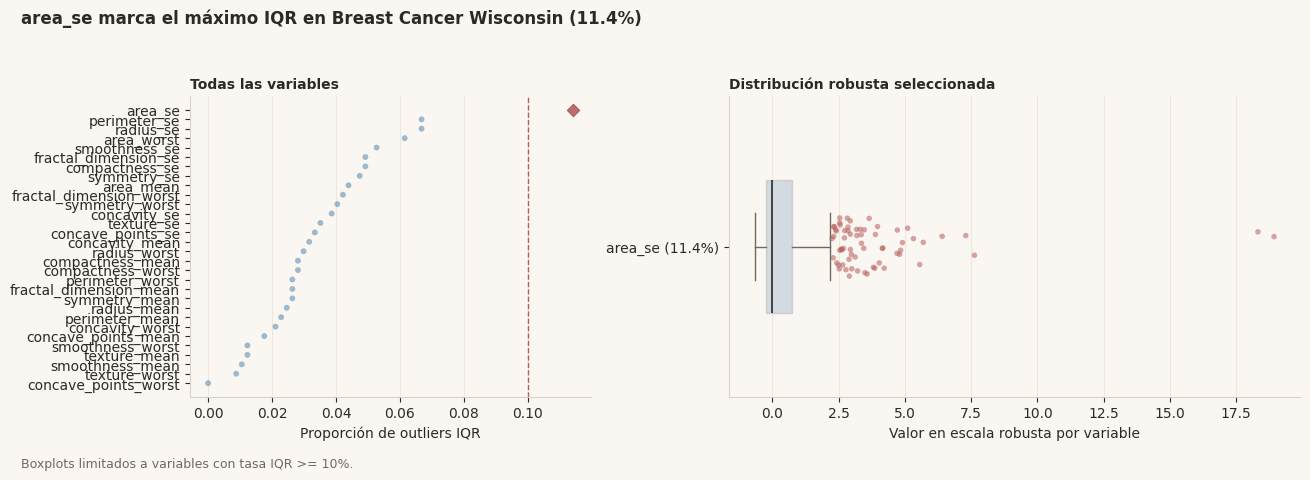

In [58]:
outliers_breast_cancer_wisconsin = resumir_outliers("breast_cancer_wisconsin", breast_cancer_wisconsin)
outliers_top_breast_cancer_wisconsin = outliers_breast_cancer_wisconsin.sort_values("pct_outliers_iqr", ascending=False)

mostrar_tabla(outliers_top_breast_cancer_wisconsin, "Outliers IQR - Breast Cancer Wisconsin", n=12)
graficar_outliers_dataset(outliers_breast_cancer_wisconsin, "breast_cancer_wisconsin")


`area_se` alcanza la mayor tasa IQR con 65 outliers y 11.4%. No se capan valores en esta fase.


### Outliers IQR: `customer_churn`


**Outliers IQR - Customer Churn** - se muestran las primeras 7 filas de 7.

,Dataset,Variable,q1,q3,IQR,Límite inferior,Límite superior,Outliers IQR,Proporción de outliers IQR
0,customer_churn,age,29.0,48.0,19.0,0.5,76.5,0,0.0
1,customer_churn,tenure,16.0,46.0,30.0,-29.0,91.0,0,0.0
2,customer_churn,usage_frequency,9.0,23.0,14.0,-12.0,44.0,0,0.0
3,customer_churn,support_calls,1.0,6.0,5.0,-6.5,13.5,0,0.0
4,customer_churn,payment_delay,6.0,19.0,13.0,-13.5,38.5,0,0.0
5,customer_churn,total_spend,480.0,830.0,350.0,-45.0,1355.0,0,0.0
6,customer_churn,last_interaction,7.0,22.0,15.0,-15.5,44.5,0,0.0


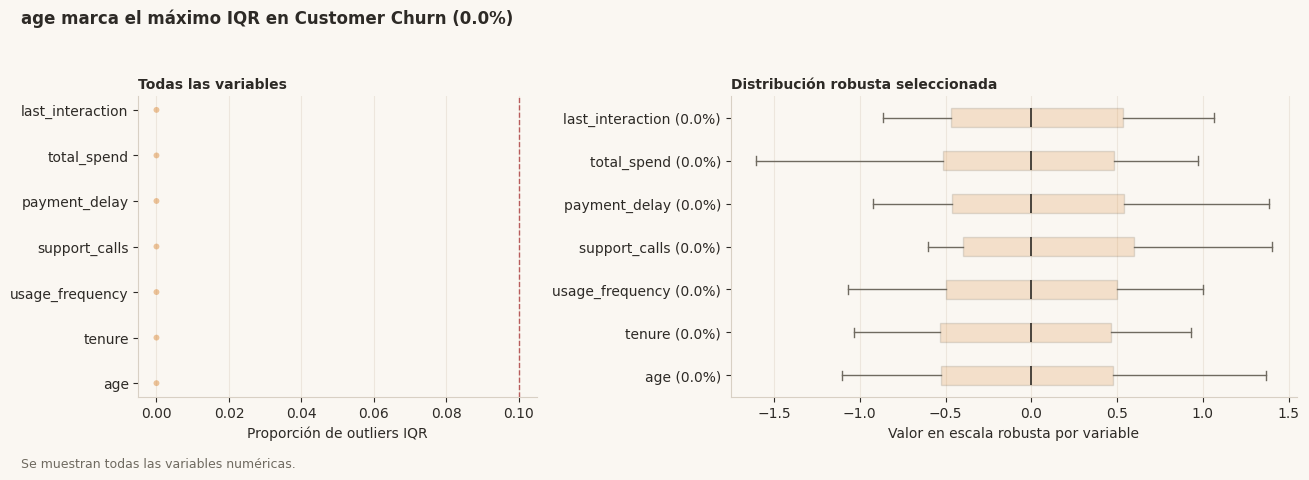

In [59]:
outliers_customer_churn = resumir_outliers("customer_churn", customer_churn)
outliers_top_customer_churn = outliers_customer_churn.sort_values("pct_outliers_iqr", ascending=False)

mostrar_tabla(outliers_top_customer_churn, "Outliers IQR - Customer Churn", n=12)
graficar_outliers_dataset(outliers_customer_churn, "customer_churn")


Las 7 variables numéricas tienen 0 outliers IQR. No se aplica winsorización.


### Outliers IQR: `madelon`


**Outliers IQR - Madelon** - se muestran las primeras 12 filas de 500.

,Dataset,Variable,q1,q3,IQR,Límite inferior,Límite superior,Outliers IQR,Proporción de outliers IQR
423,madelon,feat_423,476.0,476.00,0.00,476.000,476.000,748,0.3740
90,madelon,feat_90,476.0,476.00,0.00,476.000,476.000,679,0.3395
198,madelon,feat_198,476.0,477.00,1.00,474.500,478.500,286,0.1430
7,madelon,feat_7,476.0,477.00,1.00,474.500,478.500,284,0.1420
120,madelon,feat_120,475.0,477.25,2.25,471.625,480.625,75,0.0375
332,madelon,feat_332,476.0,477.00,1.00,474.500,478.500,71,0.0355
228,madelon,feat_228,476.0,477.00,1.00,474.500,478.500,53,0.0265
392,madelon,feat_392,475.0,478.00,3.00,470.500,482.500,52,0.0260
368,madelon,feat_368,477.0,492.00,15.00,454.500,514.500,44,0.0220
364,madelon,feat_364,478.0,484.00,6.00,469.000,493.000,39,0.0195


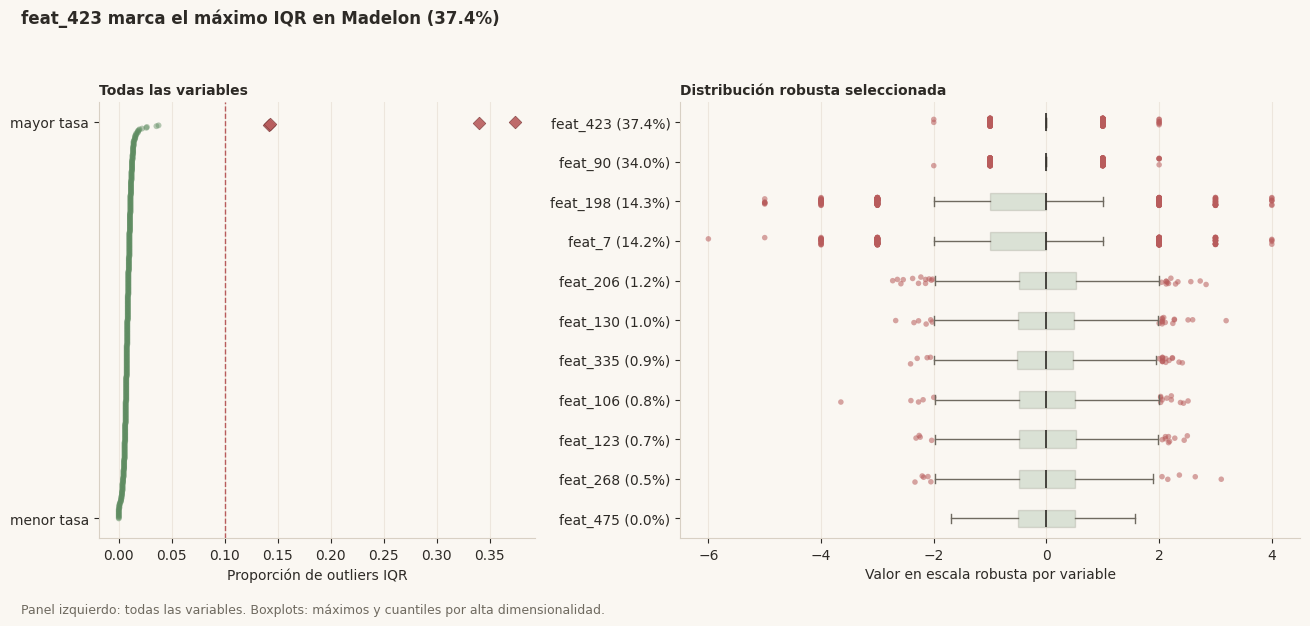

In [60]:
outliers_madelon = resumir_outliers("madelon", madelon)
outliers_top_madelon = outliers_madelon.sort_values("pct_outliers_iqr", ascending=False)

mostrar_tabla(outliers_top_madelon, "Outliers IQR - Madelon", n=12)
graficar_outliers_dataset(outliers_madelon, "madelon")


El panel de tasas recorre las 500 variables. Los boxplots muestran una selección por máximos y cuantiles; al tratarse de un benchmark sintético, los extremos IQR describen la construcción marginal y el ruido, no errores a corregir en Fase 2.


### Outliers IQR: `olive_oil`


**Outliers IQR - Olive Oil** - se muestran las primeras 10 filas de 10.

,Dataset,Variable,q1,q3,IQR,Límite inferior,Límite superior,Outliers IQR,Proporción de outliers IQR
8,olive_oil,eicosenoic,50.00,70.00,20.00,20.000,100.000,51,0.0892
7,olive_oil,arachidic,26.00,40.25,14.25,4.625,61.625,32,0.0559
4,olive_oil,oleic,205.00,249.00,44.00,139.000,315.000,17,0.0297
2,olive_oil,palmitoleic,1095.00,1360.00,265.00,697.500,1757.500,1,0.0017
1,olive_oil,palmitic,3.00,7.00,4.00,-3.000,13.000,0,0.0000
0,olive_oil,area,1.00,3.00,2.00,-2.000,6.000,0,0.0000
5,olive_oil,linoleic,7000.00,7680.00,680.00,5980.000,8700.000,0,0.0000
3,olive_oil,stearic,87.75,169.25,81.50,-34.500,291.500,0,0.0000
6,olive_oil,linolenic,770.75,1180.75,410.00,155.750,1795.750,0,0.0000
9,olive_oil,other,2.00,28.00,26.00,-37.000,67.000,0,0.0000


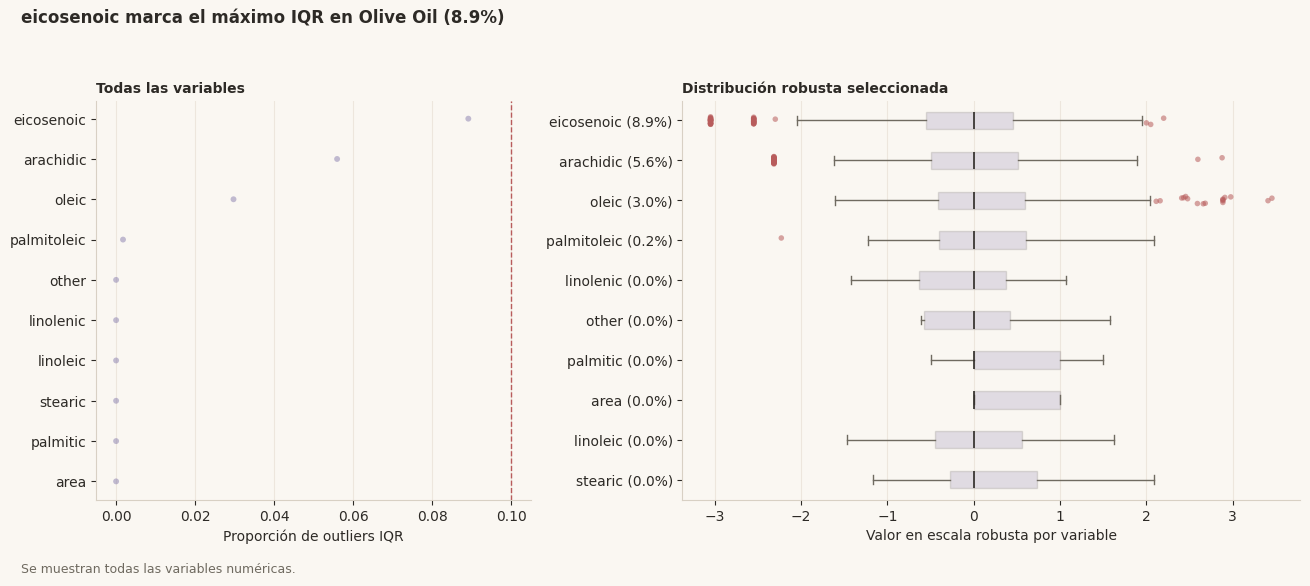

In [61]:
outliers_olive_oil = resumir_outliers("olive_oil", olive_oil)
outliers_top_olive_oil = outliers_olive_oil.sort_values("pct_outliers_iqr", ascending=False)

mostrar_tabla(outliers_top_olive_oil, "Outliers IQR - Olive Oil", n=12)
graficar_outliers_dataset(outliers_olive_oil, "olive_oil")


`eicosenoic` presenta 51 outliers IQR y 8.9%, todavía por debajo del umbral visual del 10%. No se eliminan filas ni se transforman variables.


### Resumen Comparativo de Outliers


In [62]:
outlier_by_variable = pd.concat([
    outliers_breast_cancer_wisconsin,
    outliers_customer_churn,
    outliers_madelon,
    outliers_olive_oil,
], ignore_index=True)

outlier_summary = outlier_by_variable.groupby("dataset", as_index=False).agg(
    variables_numericas=("variable", "count"),
    pct_outliers_media=("pct_outliers_iqr", "mean"),
    pct_outliers_maxima=("pct_outliers_iqr", "max"),
)

guardar_tabla(outlier_by_variable, "fase2_outliers_iqr.csv")
mostrar_tabla(outlier_summary, "Resumen de outliers")


**Resumen de outliers** - se muestran las primeras 4 filas de 4.

,Dataset,Variables numéricas,Proporción media de outliers IQR,Proporción máxima de outliers IQR
0,breast_cancer_wisconsin,30,0.0356,0.1142
1,customer_churn,7,0.0000,0.0000
2,madelon,500,0.0104,0.3740
3,olive_oil,10,0.0177,0.0892


El agregado de outliers cubre 547 variables numéricas. `madelon` domina la escala con media 0.0104 y máximo 0.3740, `breast_cancer_wisconsin` queda con media 0.0356 y máximo 0.1142, `olive_oil` alcanza 0.0892 y `customer_churn` permanece en 0.0000. Las figuras siguientes separan la vista completa del zoom 0-5% para que el máximo de `madelon` no oculte las diferencias pequeñas.


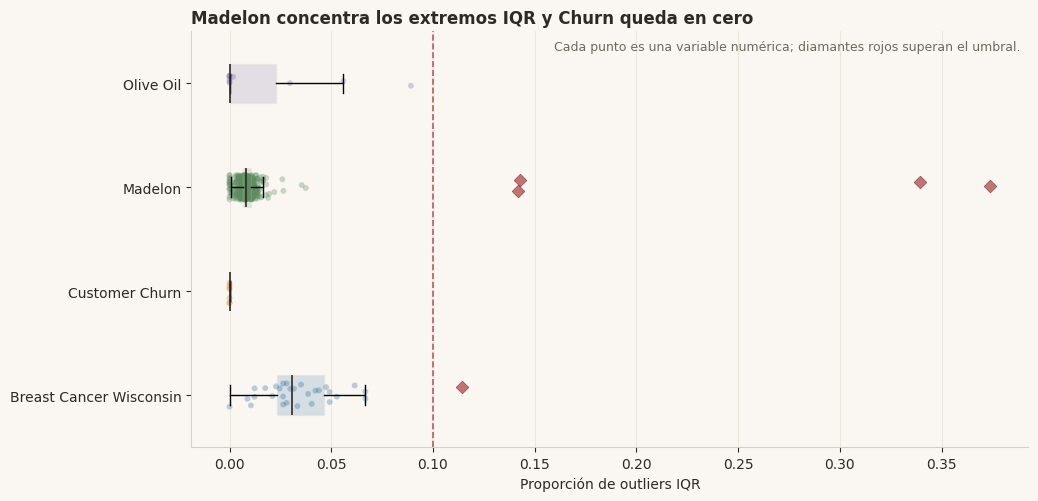

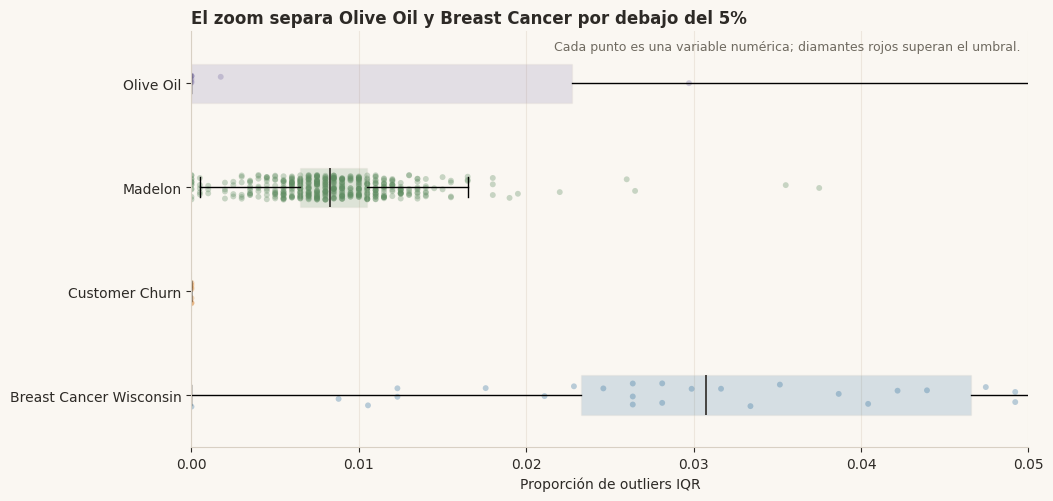

In [63]:
graficar_resumen_outliers(
    outlier_by_variable,
    "fase2_outliers_iqr_resumen_completo.png",
    "Madelon concentra los extremos IQR y Churn queda en cero",
)

graficar_resumen_outliers(
    outlier_by_variable,
    "fase2_outliers_iqr_resumen_zoom.png",
    "El zoom separa Olive Oil y Breast Cancer por debajo del 5%",
    xlim=0.05,
)


El resumen de outliers muestra tres comportamientos. `customer_churn` tiene 7 variables numéricas con 0.0000 de tasa máxima; `olive_oil` alcanza 0.0892 en `eicosenoic`, por debajo del umbral visual del 10%; y `breast_cancer_wisconsin` supera el umbral solo en `area_se`, con 65 casos y 0.1142 de tasa. `madelon` es el caso extremo: 4 variables superan el 10% y `feat_423` llega a 0.3740, coherente con un benchmark sintético que no debe winsorizarse aquí.


## 2.10 Codificación del Target y Revisión de Categóricas

Se codifica el target de forma determinista y se enumeran las categorías observadas en variables predictoras. Esta sección prepara el terreno para estimadores posteriores: no codifica predictoras categóricas de forma global antes del split.

PAPER_QFS, sección V.A, aplica esta misma decisión para hacer compatibles los datos mixtos con métricas de información mutua y redundancia: las variables categóricas se transforman a códigos enteros mediante *label encoding* y los campos no numéricos se eliminan o imputan cuando procede. En esta fase se codifica el target y se documentan las predictoras categóricas; la codificación global de predictoras se pospone porque el `OneHotEncoder` real aprende categorías durante `fit` y debe ajustarse solo con train para evitar *data leakage*.


In [64]:
def construir_mapa_target(serie_target):
    target_values = [convertir_escalar_python(value) for value in serie_target.dropna().unique().tolist()]
    target_values = sorted(target_values, key=lambda value: str(value))
    return {target_value: position for position, target_value in enumerate(target_values)}


def resumir_target_codificado(nombre_dataset, datos_dataset):
    target_name = expected_targets[nombre_dataset]
    target_map = construir_mapa_target(datos_dataset[target_name])
    target_counts = datos_dataset[target_name].value_counts(dropna=False).reset_index()
    target_counts.columns = ["valor_original", "n"]
    target_counts["dataset"] = nombre_dataset
    target_counts["target"] = processed_targets[nombre_dataset]
    target_counts["codigo"] = target_counts["valor_original"].map(target_map)
    target_counts["proporcion"] = target_counts["n"] / len(datos_dataset)
    return target_counts[["dataset", "target", "valor_original", "codigo", "n", "proporcion"]], target_map


In [65]:
def crear_filas_categoria(nombre_dataset, serie, variable_name):
    counts = serie.value_counts(dropna=False)
    return [{"dataset": nombre_dataset, "variable": rename_maps[nombre_dataset][variable_name], "categoria": category, "n": int(count), "proporcion": count / len(serie)} for category, count in counts.items()]


def resumir_categorias_predictoras(nombre_dataset, datos_dataset):
    target_name = expected_targets[nombre_dataset]
    predictors = datos_dataset.drop(columns=[target_name])
    categorical_predictors = predictors.select_dtypes(exclude=np.number)
    rows = []
    for variable_name in categorical_predictors.columns:
        rows.extend(crear_filas_categoria(nombre_dataset, datos_dataset[variable_name], variable_name))
    return pd.DataFrame(rows, columns=["dataset", "variable", "categoria", "n", "proporcion"])


def nombre_archivo_seguro(texto):
    return re.sub(r"[^0-9a-zA-Z_]+", "_", str(texto).lower()).strip("_")


def graficar_categoria_predictora(categories_table, dataset_name, variable_name):
    selected = categories_table[categories_table["variable"].eq(variable_name)].copy()
    if selected.empty:
        return None

    selected_for_bars = selected.sort_values("proporcion", ascending=True)
    focus_index = selected_for_bars["proporcion"].idxmax()
    focus_category = str(selected_for_bars.loc[focus_index, "categoria"])
    focus_value = float(selected_for_bars.loc[focus_index, "proporcion"])
    bar_colors = ["#B8B0A3" if idx != focus_index else DATASET_COLORS[dataset_name] for idx in selected_for_bars.index]

    figura, eje = plt.subplots(figsize=(8.4, max(3.2, 0.48 * len(selected_for_bars) + 1.8)))
    eje.barh(selected_for_bars["categoria"].astype(str), selected_for_bars["proporcion"], color=bar_colors, alpha=0.90)
    eje.set_xlim(0, min(1.0, max(0.6, selected_for_bars["proporcion"].max() * 1.20)))
    eje.set_xlabel("Proporción de filas")
    eje.set_title(f"`{focus_category}` concentra {focus_value:.1%} de `{variable_name}`", loc="left", fontweight="bold", fontsize=11)
    for y_position, (_, row) in enumerate(selected_for_bars.iterrows()):
        eje.text(row["proporcion"] + 0.01, y_position, f"{row['n']} ({row['proporcion']:.1%})", va="center", fontsize=9, color="#2D2A26")
    aplicar_estilo_eje(eje, eje_rejilla="x")
    figura.tight_layout()
    guardar_figura(figura, f"fase2_categorica_{dataset_name}_{nombre_archivo_seguro(variable_name)}.png")
    plt.show()
    plt.close(figura)
    return None


def graficar_categorias_predictoras(categories_table, dataset_name):
    if categories_table.empty:
        display(Markdown("No hay predictoras categóricas que visualizar en este dataset."))
        return None

    variables = categories_table["variable"].drop_duplicates().tolist()
    for variable_name in variables:
        graficar_categoria_predictora(categories_table, dataset_name, variable_name)
    return None


In [66]:
def obtener_ancho_variable_codificada(renamed_dataset, variable_name):
    if pd.api.types.is_numeric_dtype(renamed_dataset[variable_name]):
        return 1
    return renamed_dataset[variable_name].nunique(dropna=True)


def contar_columnas_onehot(renamed_dataset, predictors):
    total_columns = 0
    for variable_name in predictors:
        total_columns += obtener_ancho_variable_codificada(renamed_dataset, variable_name)
    return total_columns


def crear_fila_dimensionalidad_encoding(nombre_dataset, datos_dataset):
    target_name = expected_targets[nombre_dataset]
    renamed_dataset = datos_dataset.rename(columns=rename_maps[nombre_dataset])
    removed_columns = set(identifier_columns_processed[nombre_dataset])
    predictors = [name for name in renamed_dataset.columns if name != processed_targets[nombre_dataset] and name not in removed_columns]
    categorical_count = sum(not pd.api.types.is_numeric_dtype(renamed_dataset[name]) for name in predictors)
    onehot_columns = contar_columnas_onehot(renamed_dataset, predictors)
    return {"dataset": nombre_dataset, "predictoras_sin_onehot": len(predictors), "predictoras_categoricas": categorical_count, "predictoras_si_onehot": onehot_columns}


def resumen_textual_encoding(encoding_table):
    lines = ["**Resumen de codificación de predictoras.**"]
    for _, row in encoding_table.iterrows():
        dataset_label = etiqueta_dataset(row["dataset"])
        if row["predictoras_categoricas"] == 0:
            lines.append(f"- {dataset_label}: no tiene predictoras categóricas tras excluir identificadores.")
        else:
            lines.append(
                f"- {dataset_label}: {int(row['predictoras_categoricas'])} predictoras categóricas; "
                f"si se codifican con one-hot, las predictoras pasarían de {int(row['predictoras_sin_onehot'])} "
                f"a {int(row['predictoras_si_onehot'])}. El fit del encoder debe hacerse solo con train."
            )
    return "\n".join(lines)


### Target y Categóricas: `breast_cancer_wisconsin`


In [67]:
target_encoding_breast_cancer_wisconsin, target_map_breast_cancer_wisconsin = resumir_target_codificado("breast_cancer_wisconsin", breast_cancer_wisconsin)
categories_breast_cancer_wisconsin = resumir_categorias_predictoras("breast_cancer_wisconsin", breast_cancer_wisconsin)

mostrar_tabla(target_encoding_breast_cancer_wisconsin, "Codificación del target - Breast Cancer Wisconsin", n=12)
mostrar_tabla(categories_breast_cancer_wisconsin, "Categorías predictoras observadas - Breast Cancer Wisconsin", n=12)
graficar_categorias_predictoras(categories_breast_cancer_wisconsin, "breast_cancer_wisconsin")


**Codificación del target - Breast Cancer Wisconsin** - se muestran las primeras 2 filas de 2.

,Dataset,Target,Valor original,Código,N,Proporción
0,breast_cancer_wisconsin,target,B,0,357,0.6274
1,breast_cancer_wisconsin,target,M,1,212,0.3726


**Categorías predictoras observadas - Breast Cancer Wisconsin** - se muestran las primeras 0 filas de 0.

,Dataset,Variable,Categoría,N,Proporción


No hay predictoras categóricas que visualizar en este dataset.

El target binario queda codificado con 2 valores: 357 casos `B` y 212 `M`. No hay predictoras categóricas tras excluir el target.


### Target y Categóricas: `customer_churn`


**Codificación del target - Customer Churn** - se muestran las primeras 2 filas de 2.

,Dataset,Target,Valor original,Código,N,Proporción
0,customer_churn,target,1.0,1,249999,0.5671
1,customer_churn,target,0.0,0,190833,0.4329


**Categorías predictoras observadas - Customer Churn** - se muestran las primeras 8 filas de 8.

,Dataset,Variable,Categoría,N,Proporción
0,customer_churn,gender,Male,250252,0.5677
1,customer_churn,gender,Female,190580,0.4323
2,customer_churn,subscription_type,Standard,149128,0.3383
3,customer_churn,subscription_type,Premium,148678,0.3373
4,customer_churn,subscription_type,Basic,143026,0.3244
5,customer_churn,contract_length,Annual,177198,0.4020
6,customer_churn,contract_length,Quarterly,176530,0.4004
7,customer_churn,contract_length,Monthly,87104,0.1976


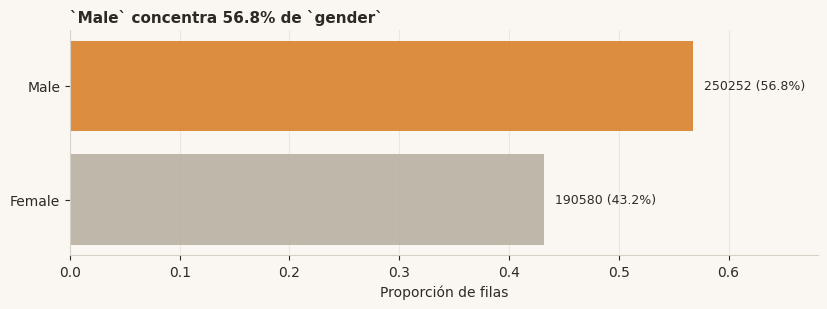

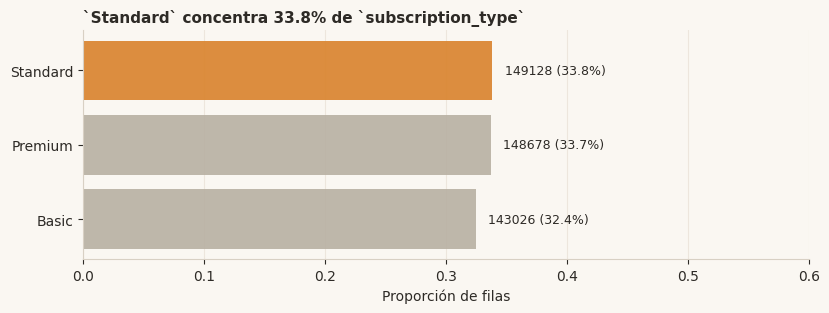

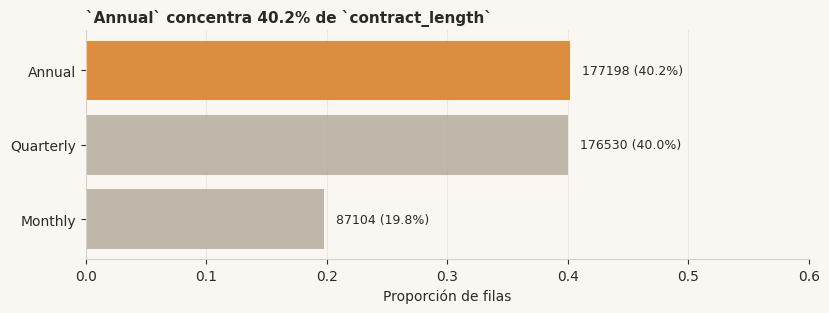

In [68]:
target_encoding_customer_churn, target_map_customer_churn = resumir_target_codificado("customer_churn", customer_churn)
categories_customer_churn = resumir_categorias_predictoras("customer_churn", customer_churn)

mostrar_tabla(target_encoding_customer_churn, "Codificación del target - Customer Churn", n=12)
mostrar_tabla(categories_customer_churn, "Categorías predictoras observadas - Customer Churn", n=12)
graficar_categorias_predictoras(categories_customer_churn, "customer_churn")


El target contiene 249999 casos codificados como 1 y 190833 como 0. Las 3 predictoras categóricas se dejan sin one-hot global; aquí solo se mide su cardinalidad.


### Target y Categóricas: `madelon`


In [69]:
target_encoding_madelon, target_map_madelon = resumir_target_codificado("madelon", madelon)
categories_madelon = resumir_categorias_predictoras("madelon", madelon)

mostrar_tabla(target_encoding_madelon, "Codificación del target - Madelon", n=12)
mostrar_tabla(categories_madelon, "Categorías predictoras observadas - Madelon", n=12)
graficar_categorias_predictoras(categories_madelon, "madelon")


**Codificación del target - Madelon** - se muestran las primeras 2 filas de 2.

,Dataset,Target,Valor original,Código,N,Proporción
0,madelon,target,-1,0,1000,0.5
1,madelon,target,1,1,1000,0.5


**Categorías predictoras observadas - Madelon** - se muestran las primeras 0 filas de 0.

,Dataset,Variable,Categoría,N,Proporción


No hay predictoras categóricas que visualizar en este dataset.

El target binario queda equilibrado con 1000 casos en -1 y 1000 en 1. No hay predictoras categóricas.


### Target y Categóricas: `olive_oil`


In [70]:
target_encoding_olive_oil, target_map_olive_oil = resumir_target_codificado("olive_oil", olive_oil)
categories_olive_oil = resumir_categorias_predictoras("olive_oil", olive_oil)

mostrar_tabla(target_encoding_olive_oil, "Codificación del target - Olive Oil", n=12)
mostrar_tabla(categories_olive_oil, "Categorías predictoras observadas - Olive Oil", n=12)
graficar_categorias_predictoras(categories_olive_oil, "olive_oil")


**Codificación del target - Olive Oil** - se muestran las primeras 9 filas de 9.

,Dataset,Target,Valor original,Código,N,Proporción
0,olive_oil,target,South-Apulia,6,206,0.3601
1,olive_oil,target,Inland-Sardinia,3,65,0.1136
2,olive_oil,target,Calabria,0,56,0.0979
3,olive_oil,target,Umbria,7,51,0.0892
4,olive_oil,target,West-Liguria,8,50,0.0874
5,olive_oil,target,East-Liguria,2,50,0.0874
6,olive_oil,target,Sicily,5,36,0.0629
7,olive_oil,target,Coast-Sardinia,1,33,0.0577
8,olive_oil,target,North-Apulia,4,25,0.0437


**Categorías predictoras observadas - Olive Oil** - se muestran las primeras 0 filas de 0.

,Dataset,Variable,Categoría,N,Proporción


No hay predictoras categóricas que visualizar en este dataset.

El target de 9 clases se codifica con una tabla explícita de correspondencias. La formulación de 3 clases con `area` ya quedó registrada en 2.3 y se separará como problema propio antes de entrenar.


### Resumen Comparativo de Codificación


In [71]:
target_maps = {
    "breast_cancer_wisconsin": target_map_breast_cancer_wisconsin,
    "customer_churn": target_map_customer_churn,
    "madelon": target_map_madelon,
    "olive_oil": target_map_olive_oil,
}

target_encoding_long = pd.concat([
    target_encoding_breast_cancer_wisconsin,
    target_encoding_customer_churn,
    target_encoding_madelon,
    target_encoding_olive_oil,
], ignore_index=True)

predictor_categories = pd.concat([
    categories_breast_cancer_wisconsin,
    categories_customer_churn,
    categories_madelon,
    categories_olive_oil,
], ignore_index=True)

encoding_dimensions = pd.DataFrame([
    crear_fila_dimensionalidad_encoding(dataset_name, raw_datasets[dataset_name])
    for dataset_name in DATASET_ORDER
])

guardar_tabla(target_encoding_long, "fase2_codificacion_target.csv")
guardar_tabla(predictor_categories, "fase2_categorias_predictoras.csv")
guardar_tabla(encoding_dimensions, "fase2_dimensionalidad_encoding.csv")
mostrar_tabla(encoding_dimensions, "Dimensionalidad potencial de categóricas")
display(Markdown(resumen_textual_encoding(encoding_dimensions)))


**Dimensionalidad potencial de categóricas** - se muestran las primeras 4 filas de 4.

,Dataset,Predictoras sin one-hot,Predictoras categóricas,Predictoras con one-hot
0,breast_cancer_wisconsin,30,0,30
1,customer_churn,10,3,15
2,madelon,500,0,500
3,olive_oil,10,0,10


**Resumen de codificación de predictoras.**
- Breast Cancer Wisconsin: no tiene predictoras categóricas tras excluir identificadores.
- Customer Churn: 3 predictoras categóricas; si se codifican con one-hot, las predictoras pasarían de 10 a 15. El fit del encoder debe hacerse solo con train.
- Madelon: no tiene predictoras categóricas tras excluir identificadores.
- Olive Oil: no tiene predictoras categóricas tras excluir identificadores.

La codificación deja 15 filas de correspondencia de target: 2 clases en `breast_cancer_wisconsin`, 2 en `customer_churn`, 2 en `madelon` y 9 en `olive_oil`. Solo `customer_churn` contiene predictoras categóricas, con 3 variables y 8 categorías observadas; si se aplicara one-hot, pasaría de 10 a 15 predictoras. Esa cifra es una estimación, no un ajuste global, y encaja con PAPER_QFS V.A porque la compatibilidad con información mutua requiere representaciones discretas trazables.


## 2.11 Escalado y Transformaciones Numéricas

Se revisan rangos, IQR y forma aproximada de las variables numéricas para saber qué necesitarán los modelos posteriores. No se ajusta ningún escalador en esta fase.


In [72]:
def crear_fila_rango(nombre_dataset, serie):
    first_quartile, third_quartile, interquartile_range, _, _ = calcular_limites_iqr(serie)
    return {
        "dataset": nombre_dataset,
        "variable": serie.name,
        "minimo": float(serie.min()),
        "maximo": float(serie.max()),
        "rango": float(serie.max() - serie.min()),
        "mediana": float(serie.median()),
        "iqr": float(interquartile_range),
    }


def resumir_rangos_numericos(nombre_dataset, datos_dataset):
    numeric_predictors = obtener_predictoras_numericas_renombradas(nombre_dataset, datos_dataset)
    return pd.DataFrame([crear_fila_rango(nombre_dataset, numeric_predictors[name]) for name in numeric_predictors.columns])


def seleccionar_variables_distribucion(ranges_table, max_variables=36):
    if len(ranges_table) <= max_variables:
        return ranges_table["variable"].tolist()

    ordered = ranges_table.sort_values("rango").reset_index(drop=True)
    positions = np.linspace(0, len(ordered) - 1, max_variables).round().astype(int)
    selected = ordered.iloc[positions]["variable"].tolist()
    return list(dict.fromkeys(selected))


def graficar_distribuciones_numericas(nombre_dataset, datos_dataset, ranges_table, max_variables=36):
    numeric_predictors = obtener_predictoras_numericas_renombradas(nombre_dataset, datos_dataset)
    selected_variables = seleccionar_variables_distribucion(ranges_table, max_variables=max_variables)
    selected_variables = [name for name in selected_variables if name in numeric_predictors.columns]
    if not selected_variables:
        display(Markdown("No hay predictoras numéricas que visualizar en este dataset."))
        return None

    n_columns = 4 if len(selected_variables) <= 16 else 6
    n_rows = int(np.ceil(len(selected_variables) / n_columns))
    figura, axes = plt.subplots(n_rows, n_columns, figsize=(2.75 * n_columns, 2.25 * n_rows), squeeze=False)

    for eje, variable_name in zip(axes.ravel(), selected_variables):
        values = numeric_predictors[variable_name].dropna()
        eje.hist(values, bins=28, density=True, color=DATASET_COLORS[nombre_dataset], alpha=0.78)
        eje.axvline(values.median(), color="#2D2A26", linewidth=1.0)
        eje.set_title(variable_name, fontsize=8, loc="left")
        eje.set_yticks([])
        aplicar_estilo_eje(eje, eje_rejilla="x")

    for eje in axes.ravel()[len(selected_variables):]:
        eje.axis("off")

    if len(ranges_table) > len(selected_variables):
        max_range_row = ranges_table.loc[ranges_table["rango"].idxmax()]
        figura.suptitle(
            f"{max_range_row['variable']} fija el mayor rango en {etiqueta_dataset(nombre_dataset)} ({max_range_row['rango']:.1f})",
            x=0.01,
            ha="left",
            fontweight="bold",
        )
    else:
        max_range_row = ranges_table.loc[ranges_table["rango"].idxmax()]
        figura.suptitle(f"{max_range_row['variable']} fija el mayor rango en {etiqueta_dataset(nombre_dataset)} ({max_range_row['rango']:.1f})", x=0.01, ha="left", fontweight="bold")

    figura.tight_layout(rect=[0, 0, 1, 0.96])
    guardar_figura(figura, f"fase2_distribuciones_numericas_{nombre_dataset}.png")
    plt.show()
    plt.close(figura)
    return None


### Rangos Numéricos: `breast_cancer_wisconsin`


**Rangos numéricos - Breast Cancer Wisconsin** - se muestran las primeras 12 filas de 30.

,Dataset,Variable,Mínimo,Máximo,Rango,Mediana,IQR
23,breast_cancer_wisconsin,area_worst,185.2000,4254.000,4068.8000,686.5000,568.7000
3,breast_cancer_wisconsin,area_mean,143.5000,2501.000,2357.5000,551.1000,362.4000
13,breast_cancer_wisconsin,area_se,6.8020,542.200,535.3980,24.5300,27.3400
22,breast_cancer_wisconsin,perimeter_worst,50.4100,251.200,200.7900,97.6600,41.2900
2,breast_cancer_wisconsin,perimeter_mean,43.7900,188.500,144.7100,86.2400,28.9300
21,breast_cancer_wisconsin,texture_worst,12.0200,49.540,37.5200,25.4100,8.6400
1,breast_cancer_wisconsin,texture_mean,9.7100,39.280,29.5700,18.8400,5.6300
20,breast_cancer_wisconsin,radius_worst,7.9300,36.040,28.1100,14.9700,5.7800
12,breast_cancer_wisconsin,perimeter_se,0.7570,21.980,21.2230,2.2870,1.7510
0,breast_cancer_wisconsin,radius_mean,6.9810,28.110,21.1290,13.3700,4.0800


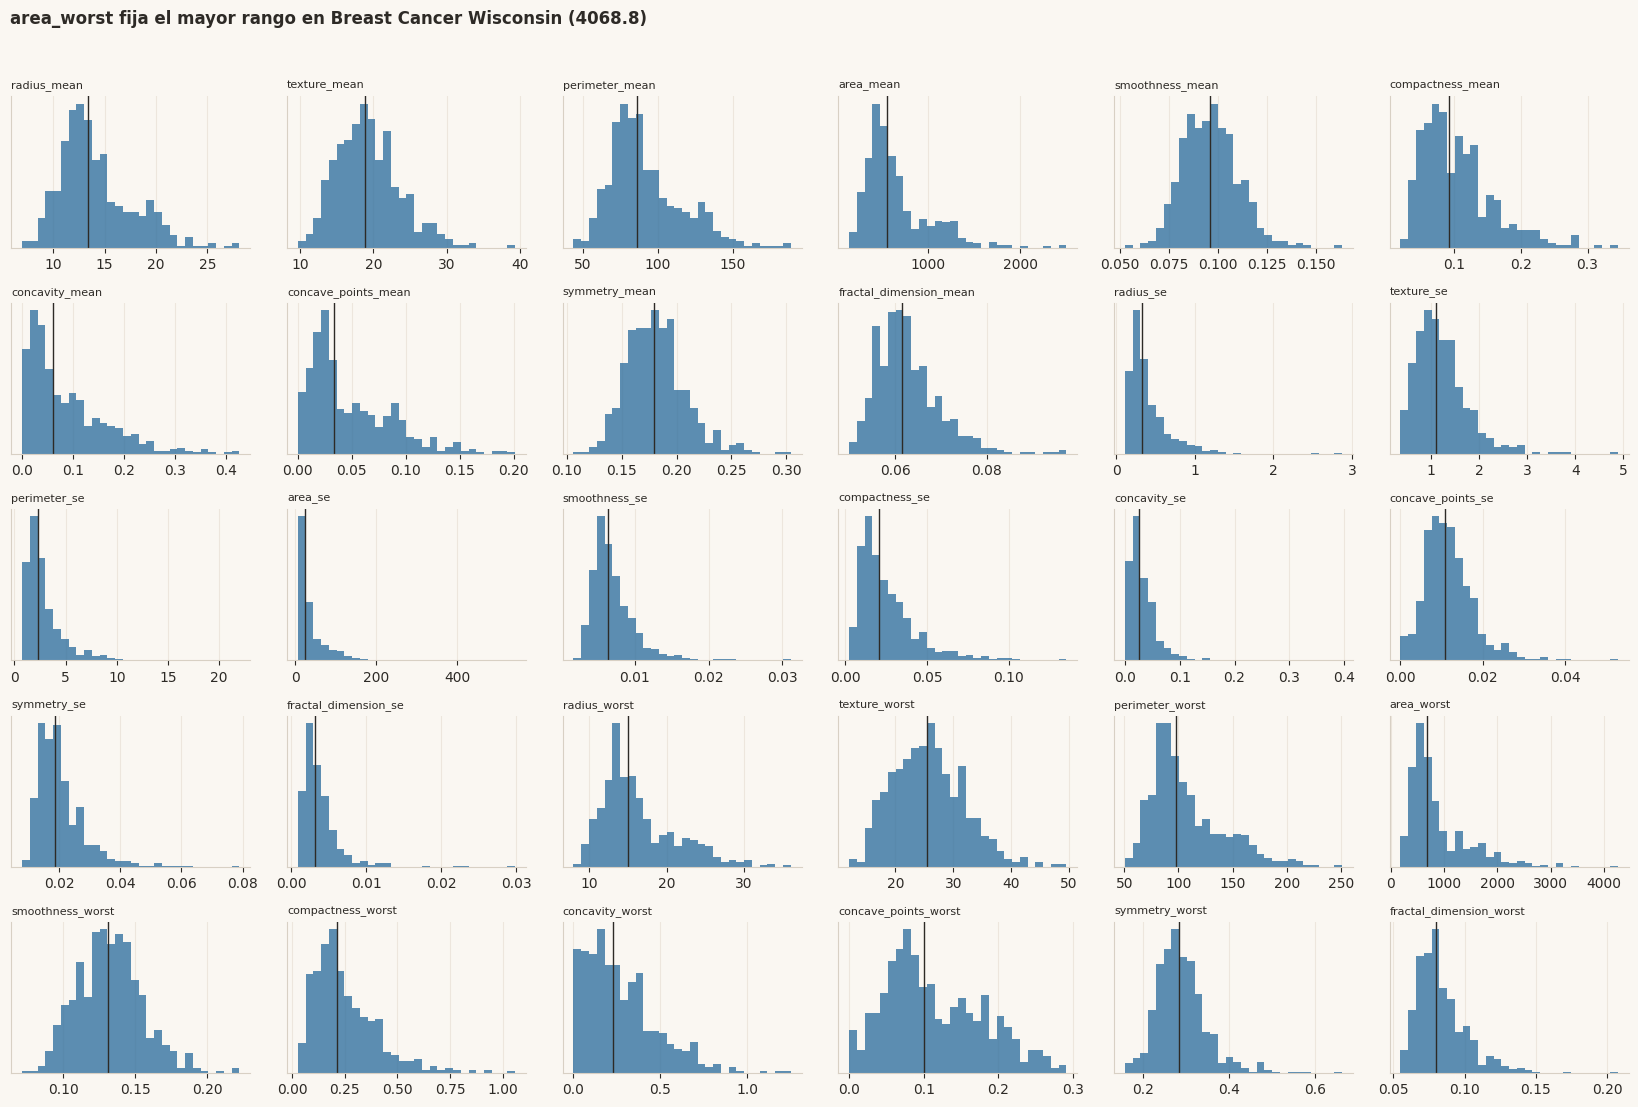

In [73]:
ranges_breast_cancer_wisconsin = resumir_rangos_numericos("breast_cancer_wisconsin", breast_cancer_wisconsin)
mostrar_tabla(ranges_breast_cancer_wisconsin.sort_values("rango", ascending=False), "Rangos numéricos - Breast Cancer Wisconsin", n=12)
graficar_distribuciones_numericas("breast_cancer_wisconsin", breast_cancer_wisconsin, ranges_breast_cancer_wisconsin)


`area_worst` alcanza rango 4068.8, muy por encima de medidas con rango inferior a 1. El escalado será relevante en estimadores posteriores.


### Rangos Numéricos: `customer_churn`


**Rangos numéricos - Customer Churn** - se muestran las primeras 7 filas de 7.

,Dataset,Variable,Mínimo,Máximo,Rango,Mediana,IQR
5,customer_churn,total_spend,100.0,1000.0,900.0,661.0,350.0
1,customer_churn,tenure,1.0,60.0,59.0,32.0,30.0
0,customer_churn,age,18.0,65.0,47.0,39.0,19.0
4,customer_churn,payment_delay,0.0,30.0,30.0,12.0,13.0
2,customer_churn,usage_frequency,1.0,30.0,29.0,16.0,14.0
6,customer_churn,last_interaction,1.0,30.0,29.0,14.0,15.0
3,customer_churn,support_calls,0.0,10.0,10.0,3.0,5.0


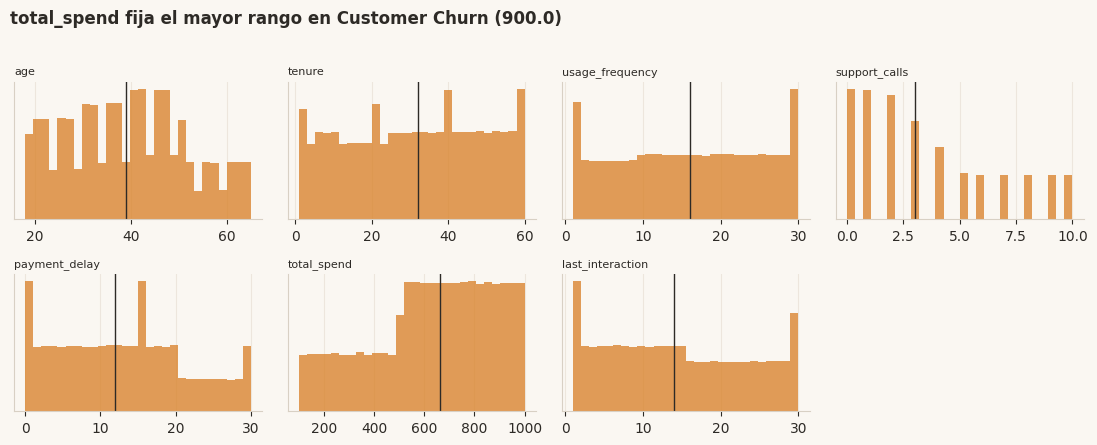

In [74]:
ranges_customer_churn = resumir_rangos_numericos("customer_churn", customer_churn)
mostrar_tabla(ranges_customer_churn.sort_values("rango", ascending=False), "Rangos numéricos - Customer Churn", n=12)
graficar_distribuciones_numericas("customer_churn", customer_churn, ranges_customer_churn)


`total_spend` alcanza rango 900.0 y la mediana de rangos es 30.0. El ajuste de escaladores se pospone al estimador posterior al split.


### Rangos Numéricos: `madelon`


**Rangos numéricos - Madelon** - se muestran las primeras 12 filas de 500.

,Dataset,Variable,Mínimo,Máximo,Rango,Mediana,IQR
105,madelon,feat_105,0.0,999.0,999.0,499.0,190.25
493,madelon,feat_493,130.0,920.0,790.0,504.0,182.00
453,madelon,feat_453,84.0,807.0,723.0,487.5,163.25
336,madelon,feat_336,180.0,828.0,648.0,483.5,144.25
153,madelon,feat_153,182.0,814.0,632.0,501.5,169.00
338,madelon,feat_338,207.0,829.0,622.0,496.0,134.25
442,madelon,feat_442,207.0,794.0,587.0,494.0,133.00
64,madelon,feat_64,214.0,768.0,554.0,500.5,124.00
455,madelon,feat_455,265.0,735.0,470.0,504.5,131.00
433,madelon,feat_433,263.0,719.0,456.0,499.5,117.00


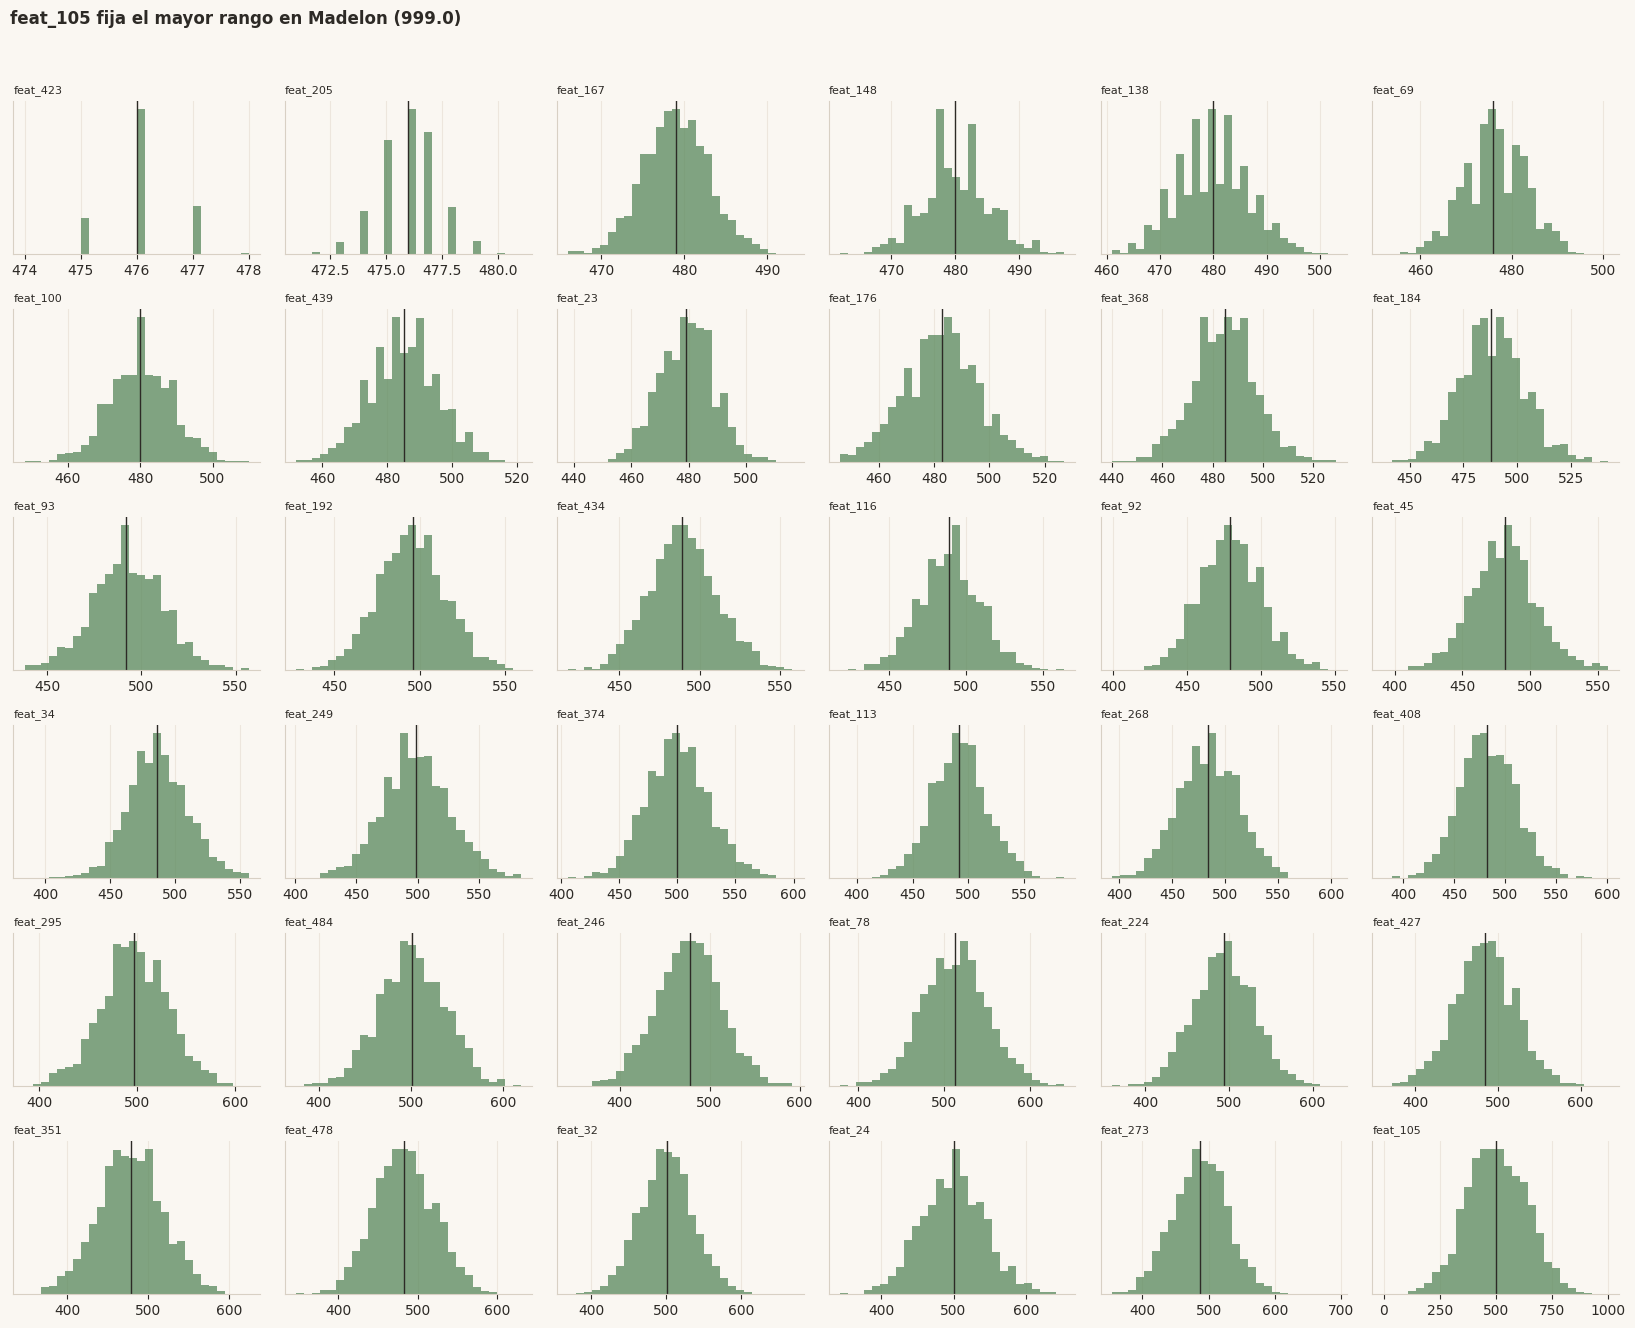

In [75]:
ranges_madelon = resumir_rangos_numericos("madelon", madelon)
mostrar_tabla(ranges_madelon.sort_values("rango", ascending=False), "Rangos numéricos - Madelon", n=12)
graficar_distribuciones_numericas("madelon", madelon, ranges_madelon)


Las 500 predictoras comparten una estructura numérica comparable, pero no se transforma el dataset completo en Fase 2.


### Rangos Numéricos: `olive_oil`


**Rangos numéricos - Olive Oil** - se muestran las primeras 10 filas de 10.

,Dataset,Variable,Mínimo,Máximo,Rango,Mediana,IQR
5,olive_oil,linoleic,6300.0,8410.0,2110.0,7302.5,680.00
2,olive_oil,palmitoleic,610.0,1753.0,1143.0,1201.0,265.00
6,olive_oil,linolenic,448.0,1470.0,1022.0,1030.0,410.00
3,olive_oil,stearic,15.0,280.0,265.0,110.0,81.50
4,olive_oil,oleic,152.0,375.0,223.0,223.0,44.00
8,olive_oil,eicosenoic,0.0,105.0,105.0,61.0,20.00
7,olive_oil,arachidic,0.0,74.0,74.0,33.0,14.25
9,olive_oil,other,1.0,58.0,57.0,17.0,26.00
1,olive_oil,palmitic,1.0,9.0,8.0,3.0,4.00
0,olive_oil,area,1.0,3.0,2.0,1.0,2.00


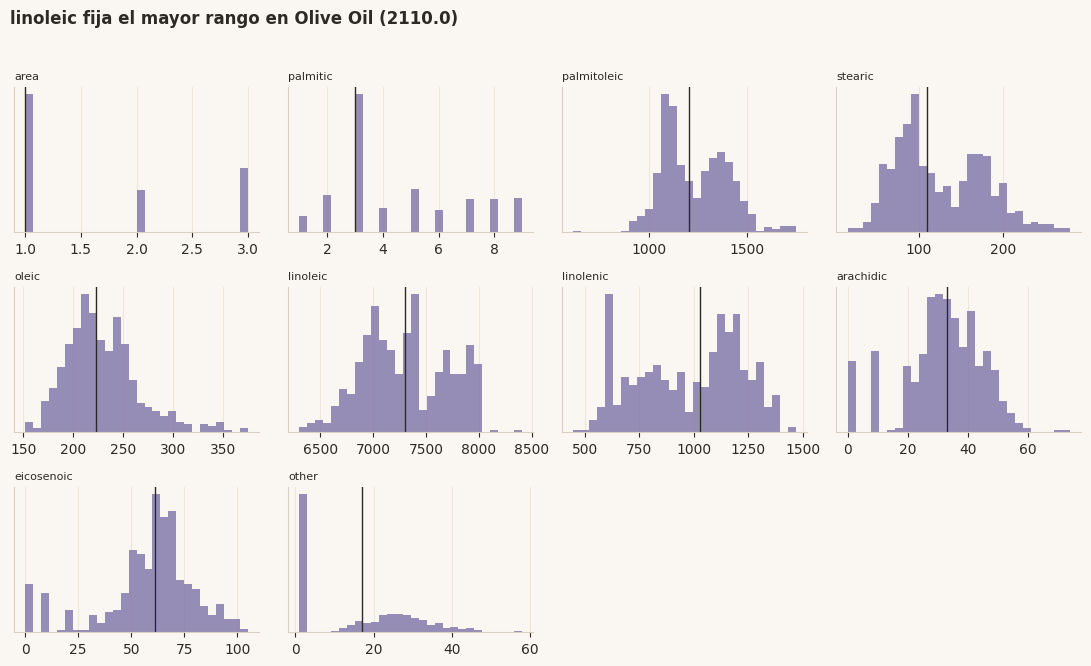

In [76]:
ranges_olive_oil = resumir_rangos_numericos("olive_oil", olive_oil)
mostrar_tabla(ranges_olive_oil.sort_values("rango", ascending=False), "Rangos numéricos - Olive Oil", n=12)
graficar_distribuciones_numericas("olive_oil", olive_oil, ranges_olive_oil)


`linoleic` alcanza rango 2110.0 y la mediana de rangos es 164.0. El escalado debe ajustarse solo con train.


### Resumen Comparativo de Rangos


In [77]:
numeric_ranges = pd.concat([
    ranges_breast_cancer_wisconsin,
    ranges_customer_churn,
    ranges_madelon,
    ranges_olive_oil,
], ignore_index=True)

range_summary = numeric_ranges.groupby("dataset", as_index=False).agg(
    variables_numericas=("variable", "count"),
    rango_mediano=("rango", "median"),
    rango_maximo=("rango", "max"),
    iqr_mediano=("iqr", "median"),
)

guardar_tabla(numeric_ranges, "fase2_rangos_numericos.csv")
mostrar_tabla(range_summary, "Resumen de rangos numéricos")


**Resumen de rangos numéricos** - se muestran las primeras 4 filas de 4.

,Dataset,Variables numéricas,Rango mediano,Rango máximo,IQR mediano
0,breast_cancer_wisconsin,30,0.467,4068.8,0.0988
1,customer_churn,7,30.000,900.0,15.0000
2,madelon,500,168.000,999.0,31.0000
3,olive_oil,10,164.000,2110.0,35.0000


Los rangos numéricos anticipan necesidades de modelado sin aplicar escalado. `madelon` acumula 500 variables con rango mediano 168.0000, mientras `customer_churn` tiene 7 variables y rango mediano 30.0000. Los máximos son grandes y heterogéneos: `area_worst` alcanza 4068.8000 en `breast_cancer_wisconsin`, `total_spend` 900.0000 en `customer_churn`, `feat_105` 999.0000 en `madelon` y `linoleic` 2110.0000 en `olive_oil`.


## 2.12 Aplicación de Transformaciones Estructurales

Tras revisar la evidencia, se aplican únicamente las transformaciones estructurales: renombrado, conversión segura de flotantes enteros, exclusión de identificadores y codificación del target. No se elimina ninguna otra variable.


In [78]:
def convertir_flotantes_enteros(datos_dataset, target_name):
    converted_dataset = datos_dataset.copy()
    for variable_name in converted_dataset.columns:
        if variable_name != target_name and es_entero_en_float(converted_dataset[variable_name]):
            converted_dataset[variable_name] = converted_dataset[variable_name].astype("int64")
    return converted_dataset


def procesar_dataset(nombre_dataset, datos_dataset):
    renamed_dataset = datos_dataset.rename(columns=rename_maps[nombre_dataset]).copy()
    processed_target = processed_targets[nombre_dataset]
    typed_dataset = convertir_flotantes_enteros(renamed_dataset, processed_target)
    without_ids = typed_dataset.drop(columns=identifier_columns_processed[nombre_dataset], errors="ignore")
    without_ids[processed_target] = without_ids[processed_target].map(target_maps[nombre_dataset]).astype("int64")
    return without_ids


In [79]:
def resumir_transformacion(nombre_dataset, datos_raw, datos_processed):
    processed_target = processed_targets[nombre_dataset]
    return pd.DataFrame([{
        "dataset": nombre_dataset,
        "filas_originales": datos_raw.shape[0],
        "filas_procesadas": datos_processed.shape[0],
        "columnas_originales": datos_raw.shape[1],
        "columnas_procesadas": datos_processed.shape[1],
        "columnas_eliminadas": datos_raw.shape[1] - datos_processed.shape[1],
        "target": processed_target,
        "target_minimo": int(datos_processed[processed_target].min()),
        "target_maximo": int(datos_processed[processed_target].max()),
        "nulos_procesados": int(datos_processed.isna().sum().sum()),
    }])


### Transformación Estructural: `breast_cancer_wisconsin`


In [80]:
processed_breast_cancer_wisconsin = procesar_dataset("breast_cancer_wisconsin", breast_cancer_wisconsin)
transformation_breast_cancer_wisconsin = resumir_transformacion("breast_cancer_wisconsin", breast_cancer_wisconsin, processed_breast_cancer_wisconsin)

mostrar_tabla(transformation_breast_cancer_wisconsin, "Transformación estructural - Breast Cancer Wisconsin")
display(processed_breast_cancer_wisconsin.head())
print(obtener_info_texto(processed_breast_cancer_wisconsin))


**Transformación estructural - Breast Cancer Wisconsin** - se muestran las primeras 1 filas de 1.

,Dataset,Filas originales,Filas procesadas,Columnas originales,Columnas procesadas,Columnas eliminadas,Target,Código mínimo del target,Código máximo del target,Nulos procesados
0,breast_cancer_wisconsin,569,569,32,31,1,target,0,1,0


,target,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave_points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.1184,0.2776,0.3001,0.1471,0.2419,0.0787,1.0950,0.9053,8.589,153.40,0.0064,0.0490,0.0537,0.0159,0.0300,0.0062,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.1189
1,1,20.57,17.77,132.90,1326.0,0.0847,0.0786,0.0869,0.0702,0.1812,0.0567,0.5435,0.7339,3.398,74.08,0.0052,0.0131,0.0186,0.0134,0.0139,0.0035,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.0890
2,1,19.69,21.25,130.00,1203.0,0.1096,0.1599,0.1974,0.1279,0.2069,0.0600,0.7456,0.7869,4.585,94.03,0.0062,0.0401,0.0383,0.0206,0.0225,0.0046,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.0876
3,1,11.42,20.38,77.58,386.1,0.1425,0.2839,0.2414,0.1052,0.2597,0.0974,0.4956,1.1560,3.445,27.23,0.0091,0.0746,0.0566,0.0187,0.0596,0.0092,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.1730
4,1,20.29,14.34,135.10,1297.0,0.1003,0.1328,0.1980,0.1043,0.1809,0.0588,0.7572,0.7813,5.438,94.44,0.0115,0.0246,0.0569,0.0188,0.0176,0.0051,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.0768


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   target                   569 non-null    int64  
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave_points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  5

El dataset procesado pasa de 32 a 31 columnas y pierde únicamente el identificador. Las variables clínicas permanecen sin selección ni escalado.


### Transformación Estructural: `customer_churn`


In [81]:
processed_customer_churn = procesar_dataset("customer_churn", customer_churn)
transformation_customer_churn = resumir_transformacion("customer_churn", customer_churn, processed_customer_churn)

mostrar_tabla(transformation_customer_churn, "Transformación estructural - Customer Churn")
display(processed_customer_churn.head())
print(obtener_info_texto(processed_customer_churn))


**Transformación estructural - Customer Churn** - se muestran las primeras 1 filas de 1.

,Dataset,Filas originales,Filas procesadas,Columnas originales,Columnas procesadas,Columnas eliminadas,Target,Código mínimo del target,Código máximo del target,Nulos procesados
0,customer_churn,440832,440832,12,11,1,target,0,1,0


,age,gender,tenure,usage_frequency,support_calls,payment_delay,subscription_type,contract_length,total_spend,last_interaction,target
0,30,Female,39,14,5,18,Standard,Annual,932.0,17,1
1,65,Female,49,1,10,8,Basic,Monthly,557.0,6,1
2,55,Female,14,4,6,18,Basic,Quarterly,185.0,3,1
3,58,Male,38,21,7,7,Standard,Monthly,396.0,29,1
4,23,Male,32,20,5,8,Basic,Monthly,617.0,20,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440832 entries, 0 to 440831
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   age                440832 non-null  int64  
 1   gender             440832 non-null  object 
 2   tenure             440832 non-null  int64  
 3   usage_frequency    440832 non-null  int64  
 4   support_calls      440832 non-null  int64  
 5   payment_delay      440832 non-null  int64  
 6   subscription_type  440832 non-null  object 
 7   contract_length    440832 non-null  object 
 8   total_spend        440832 non-null  float64
 9   last_interaction   440832 non-null  int64  
 10  target             440832 non-null  int64  
dtypes: float64(1), int64(7), object(3)
memory usage: 37.0+ MB



El dataset procesado pasa de 12 a 11 columnas, elimina `customer_id` y codifica el target. Las categóricas predictoras se mantienen para estimador posterior.


### Transformación Estructural: `madelon`


In [82]:
processed_madelon = procesar_dataset("madelon", madelon)
transformation_madelon = resumir_transformacion("madelon", madelon, processed_madelon)

mostrar_tabla(transformation_madelon, "Transformación estructural - Madelon")
display(processed_madelon.head())
print(obtener_info_texto(processed_madelon))


**Transformación estructural - Madelon** - se muestran las primeras 1 filas de 1.

,Dataset,Filas originales,Filas procesadas,Columnas originales,Columnas procesadas,Columnas eliminadas,Target,Código mínimo del target,Código máximo del target,Nulos procesados
0,madelon,2000,2000,501,501,0,target,0,1,0


,feat_0,feat_1,feat_2,feat_3,feat_4,feat_5,feat_6,feat_7,feat_8,feat_9,feat_10,feat_11,feat_12,feat_13,feat_14,feat_15,...,feat_485,feat_486,feat_487,feat_488,feat_489,feat_490,feat_491,feat_492,feat_493,feat_494,feat_495,feat_496,feat_497,feat_498,feat_499,target
0,485,477,537,479,452,471,491,476,475,473,455,500,456,507,478,491,...,476,482,463,467,479,477,481,477,485,511,485,481,479,475,496,0
1,483,458,460,487,587,475,526,479,485,469,434,483,465,503,472,478,...,507,478,483,492,485,463,478,487,338,513,486,483,492,510,517,0
2,487,542,499,468,448,471,442,478,480,477,468,497,477,491,493,502,...,486,487,480,522,481,487,481,492,650,506,501,480,489,499,498,0
3,480,491,510,485,495,472,417,474,502,476,455,520,437,472,481,436,...,468,487,458,489,490,491,480,474,572,454,469,475,482,494,461,1
4,484,502,528,489,466,481,402,478,487,468,432,494,493,434,505,497,...,482,473,473,498,485,488,479,452,435,486,508,481,504,495,511,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Columns: 501 entries, feat_0 to target
dtypes: int64(501)
memory usage: 7.6 MB



El dataset procesado conserva las 500 predictoras. No se aplica reducción dimensional en Fase 2.


### Transformación Estructural: `olive_oil`


In [83]:
processed_olive_oil = procesar_dataset("olive_oil", olive_oil)
transformation_olive_oil = resumir_transformacion("olive_oil", olive_oil, processed_olive_oil)

mostrar_tabla(transformation_olive_oil, "Transformación estructural - Olive Oil")
display(processed_olive_oil.head())
print(obtener_info_texto(processed_olive_oil))


**Transformación estructural - Olive Oil** - se muestran las primeras 1 filas de 1.

,Dataset,Filas originales,Filas procesadas,Columnas originales,Columnas procesadas,Columnas eliminadas,Target,Código mínimo del target,Código máximo del target,Nulos procesados
0,olive_oil,572,572,12,11,1,target,0,8,0


,target,area,palmitic,palmitoleic,stearic,oleic,linoleic,linolenic,arachidic,eicosenoic,other
0,4,1,1,1075,75,226,7823,672,36,60,29
1,4,1,1,1088,73,224,7709,781,31,61,29
2,4,1,1,911,54,246,8113,549,31,63,29
3,4,1,1,966,57,240,7952,619,50,78,35
4,4,1,1,1051,67,259,7771,672,50,80,46


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 572 entries, 0 to 571
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   target       572 non-null    int64
 1   area         572 non-null    int64
 2   palmitic     572 non-null    int64
 3   palmitoleic  572 non-null    int64
 4   stearic      572 non-null    int64
 5   oleic        572 non-null    int64
 6   linoleic     572 non-null    int64
 7   linolenic    572 non-null    int64
 8   arachidic    572 non-null    int64
 9   eicosenoic   572 non-null    int64
 10  other        572 non-null    int64
dtypes: int64(11)
memory usage: 49.3 KB



El dataset procesado pasa de 12 a 11 columnas, elimina `id` y codifica el target 0-8. Las variables de composición permanecen intactas.


### Resumen Comparativo de Transformaciones


In [84]:
processed_datasets = {
    "breast_cancer_wisconsin": processed_breast_cancer_wisconsin,
    "customer_churn": processed_customer_churn,
    "madelon": processed_madelon,
    "olive_oil": processed_olive_oil,
}

transformation_summary = pd.concat([
    transformation_breast_cancer_wisconsin,
    transformation_customer_churn,
    transformation_madelon,
    transformation_olive_oil,
], ignore_index=True)

guardar_tabla(transformation_summary, "fase2_transformaciones_estructurales.csv")
mostrar_tabla(transformation_summary, "Resumen de transformaciones estructurales")


**Resumen de transformaciones estructurales** - se muestran las primeras 4 filas de 4.

,Dataset,Filas originales,Filas procesadas,Columnas originales,Columnas procesadas,Columnas eliminadas,Target,Código mínimo del target,Código máximo del target,Nulos procesados
0,breast_cancer_wisconsin,569,569,32,31,1,target,0,1,0
1,customer_churn,440832,440832,12,11,1,target,0,1,0
2,madelon,2000,2000,501,501,0,target,0,1,0
3,olive_oil,572,572,12,11,1,target,0,8,0


Las transformaciones estructurales no alteran filas: los cuatro `delta_filas` son 0. Las columnas bajan en 1 para `breast_cancer_wisconsin`, `customer_churn` y `olive_oil`, exactamente por sus identificadores, y permanecen en 501 para `madelon`. Los targets procesados quedan en códigos 0-1 para los tres problemas binarios y 0-8 para `olive_oil`, sin nulos introducidos.


## 2.13 Comparación del Impacto Estadístico

Se compara cada dataset crudo con su versión procesada. Como las únicas transformaciones son estructurales, la comparación comprueba filas, columnas, target, nulos, medias, desviaciones y correlaciones.


In [85]:
def variacion_total_target(nombre_dataset, datos_raw, datos_processed):
    raw_target = expected_targets[nombre_dataset]
    processed_target = processed_targets[nombre_dataset]
    mapped_raw_target = datos_raw[raw_target].map(target_maps[nombre_dataset])
    raw_distribution = mapped_raw_target.value_counts(normalize=True, dropna=False)
    processed_distribution = datos_processed[processed_target].value_counts(normalize=True, dropna=False)
    aligned_distribution = pd.concat([raw_distribution.rename("raw"), processed_distribution.rename("processed")], axis=1).fillna(0)
    return float((aligned_distribution["raw"] - aligned_distribution["processed"]).abs().sum() / 2)


def crear_fila_impacto_estructura(nombre_dataset, datos_raw, datos_processed):
    return {
        "dataset": nombre_dataset,
        "filas_raw": datos_raw.shape[0],
        "filas_processed": datos_processed.shape[0],
        "delta_filas": datos_processed.shape[0] - datos_raw.shape[0],
        "columnas_raw": datos_raw.shape[1],
        "columnas_processed": datos_processed.shape[1],
        "delta_columnas": datos_processed.shape[1] - datos_raw.shape[1],
        "target_total_variation": variacion_total_target(nombre_dataset, datos_raw, datos_processed),
        "nulos_processed": int(datos_processed.isna().sum().sum()),
    }


def resumir_impacto_estructura(nombre_dataset):
    datos_raw = raw_datasets[nombre_dataset]
    datos_processed = processed_datasets[nombre_dataset]
    return crear_fila_impacto_estructura(nombre_dataset, datos_raw, datos_processed)


In [86]:
def resumir_target_shift(nombre_dataset):
    target_table = target_encoding_long[target_encoding_long["dataset"].eq(nombre_dataset)].copy()
    target_table["pct_raw"] = target_table["proporcion"]
    target_table["pct_processed"] = target_table["proporcion"]
    target_table["delta_abs"] = 0.0
    return target_table[["dataset", "codigo", "pct_raw", "pct_processed", "delta_abs"]]


def pares_correlacion_alta(nombre_dataset, datos_dataset):
    numeric_values = obtener_predictoras_numericas_renombradas(nombre_dataset, datos_dataset)
    if numeric_values.shape[1] < 2:
        return 0
    corr_matrix = numeric_values.corr(method="spearman").abs()
    upper_mask = np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    return int((corr_matrix.where(upper_mask) >= HIGH_CORRELATION_THRESHOLD).sum().sum())


In [87]:
def resumir_correlation_shift(nombre_dataset):
    raw_pairs = pares_correlacion_alta(nombre_dataset, raw_datasets[nombre_dataset])
    processed_pairs = pares_correlacion_alta(nombre_dataset, processed_datasets[nombre_dataset])
    return {"dataset": nombre_dataset, "pares_spearman_ge_085_raw": raw_pairs, "pares_spearman_ge_085_processed": processed_pairs, "delta_pares": processed_pairs - raw_pairs}


def crear_fila_distribution_shift(nombre_dataset, variable_name):
    original_name = {processed: original for original, processed in rename_maps[nombre_dataset].items()}.get(variable_name)
    raw_series = raw_datasets[nombre_dataset][original_name]
    processed_series = processed_datasets[nombre_dataset][variable_name]
    return {
        "dataset": nombre_dataset,
        "variable": variable_name,
        "mean_raw": float(raw_series.mean()),
        "mean_processed": float(processed_series.mean()),
        "std_raw": float(raw_series.std(ddof=0)),
        "std_processed": float(processed_series.std(ddof=0)),
        "mean_delta_abs": float(abs(raw_series.mean() - processed_series.mean())),
        "std_delta_abs": float(abs(raw_series.std(ddof=0) - processed_series.std(ddof=0))),
    }


def resumir_distribution_shift(nombre_dataset):
    rows = []
    for variable_name in processed_datasets[nombre_dataset].select_dtypes(include=np.number).columns:
        if variable_name != processed_targets[nombre_dataset]:
            rows.append(crear_fila_distribution_shift(nombre_dataset, variable_name))
    return pd.DataFrame(rows)


def graficar_impacto_preprocesado(impact_table, correlation_table):
    ordered = impact_table.set_index("dataset").loc[DATASET_ORDER].reset_index()
    correlation_ordered = correlation_table.set_index("dataset").loc[DATASET_ORDER].reset_index()
    labels = [etiqueta_dataset(name) for name in ordered["dataset"]]
    positions = np.arange(len(ordered))

    figura, (eje_columnas, eje_invariantes) = plt.subplots(
        1,
        2,
        figsize=(12.8, 5.1),
        gridspec_kw={"width_ratios": [1.0, 1.25]},
    )

    colors = [DATASET_COLORS[name] if delta != 0 else "#B8B0A3" for name, delta in zip(ordered["dataset"], ordered["delta_columnas"])]
    eje_columnas.barh(labels, ordered["delta_columnas"], color=colors, alpha=0.90)
    eje_columnas.axvline(0, color="#6F6A60", linewidth=1.0)
    eje_columnas.set_xlabel("Delta de columnas processed - raw")
    eje_columnas.set_title("Solo cambian los identificadores", loc="left", fontweight="bold", fontsize=10)
    for position, value in zip(positions, ordered["delta_columnas"]):
        eje_columnas.text(value - 0.04 if value < 0 else value + 0.04, position, f"{int(value):+d}", va="center", ha="right" if value < 0 else "left", fontsize=9)
    aplicar_estilo_eje(eje_columnas, eje_rejilla="x")

    invariant_metrics = pd.DataFrame({
        "dataset": ordered["dataset"],
        "filas": ordered["delta_filas"].abs(),
        "target": ordered["target_total_variation"].abs(),
        "nulos": ordered["nulos_processed"].abs(),
        "redundancia": correlation_ordered["delta_pares"].abs(),
    }).set_index("dataset")
    matrix = invariant_metrics.to_numpy(dtype=float)
    eje_invariantes.imshow(matrix, cmap="Greys", vmin=0, vmax=1, aspect="auto")
    eje_invariantes.set_yticks(positions)
    eje_invariantes.set_yticklabels(labels)
    eje_invariantes.set_xticks(np.arange(invariant_metrics.shape[1]))
    eje_invariantes.set_xticklabels(["filas", "target", "nulos", "pares >=0.85"], rotation=0)
    eje_invariantes.set_title("Las métricas de control quedan en cero", loc="left", fontweight="bold", fontsize=10)
    for row_idx in range(matrix.shape[0]):
        for col_idx in range(matrix.shape[1]):
            eje_invariantes.text(col_idx, row_idx, f"{matrix[row_idx, col_idx]:.0f}", ha="center", va="center", fontsize=9, color="#2D2A26")
    eje_invariantes.tick_params(axis="both", length=0)
    eje_invariantes.spines["top"].set_visible(False)
    eje_invariantes.spines["right"].set_visible(False)
    eje_invariantes.spines["left"].set_visible(False)
    eje_invariantes.spines["bottom"].set_visible(False)

    figura.suptitle("El preprocesado quita claves técnicas sin mover filas, target ni redundancia", x=0.02, ha="left", fontweight="bold")
    figura.text(0.02, 0.02, "Panel derecho: valores absolutos de delta; todos los controles deben permanecer en 0.", ha="left", va="bottom", color="#6F6A60", fontsize=9)
    figura.tight_layout(rect=[0, 0.06, 1, 0.92])
    guardar_figura(figura, "fase2_impacto_preprocesado_control.png")
    plt.show()
    plt.close(figura)
    return None


### Impacto Estadístico: `breast_cancer_wisconsin`


In [88]:
impact_breast_cancer_wisconsin = pd.DataFrame([resumir_impacto_estructura("breast_cancer_wisconsin")])
target_shift_breast_cancer_wisconsin = resumir_target_shift("breast_cancer_wisconsin")
distribution_shift_breast_cancer_wisconsin = resumir_distribution_shift("breast_cancer_wisconsin")
correlation_shift_breast_cancer_wisconsin = pd.DataFrame([resumir_correlation_shift("breast_cancer_wisconsin")])

mostrar_tabla(impact_breast_cancer_wisconsin, "Impacto estructural - Breast Cancer Wisconsin")
mostrar_tabla(target_shift_breast_cancer_wisconsin, "Estabilidad del target - Breast Cancer Wisconsin", n=12)
mostrar_tabla(correlation_shift_breast_cancer_wisconsin, "Correlación alta raw vs processed - Breast Cancer Wisconsin")


**Impacto estructural - Breast Cancer Wisconsin** - se muestran las primeras 1 filas de 1.

,Dataset,Filas crudas,Filas procesadas,Diferencia de filas,columnas_raw,columnas_processed,Diferencia de columnas,Variación total del target,nulos_processed
0,breast_cancer_wisconsin,569,569,0,32,31,-1,0.0,0


**Estabilidad del target - Breast Cancer Wisconsin** - se muestran las primeras 2 filas de 2.

,Dataset,Código,Proporción cruda,Proporción procesada,Diferencia absoluta
0,breast_cancer_wisconsin,0,0.6274,0.6274,0.0
1,breast_cancer_wisconsin,1,0.3726,0.3726,0.0


**Correlación alta raw vs processed - Breast Cancer Wisconsin** - se muestran las primeras 1 filas de 1.

,Dataset,Pares Spearman >= 0.85 crudos,Pares Spearman >= 0.85 procesados,Diferencia de pares
0,breast_cancer_wisconsin,29,29,0


La comparación muestra 0 cambios de filas y variación total del target 0.0000. El delta de columnas -1 corresponde a la exclusión del identificador.


### Impacto Estadístico: `customer_churn`


In [89]:
impact_customer_churn = pd.DataFrame([resumir_impacto_estructura("customer_churn")])
target_shift_customer_churn = resumir_target_shift("customer_churn")
distribution_shift_customer_churn = resumir_distribution_shift("customer_churn")
correlation_shift_customer_churn = pd.DataFrame([resumir_correlation_shift("customer_churn")])

mostrar_tabla(impact_customer_churn, "Impacto estructural - Customer Churn")
mostrar_tabla(target_shift_customer_churn, "Estabilidad del target - Customer Churn", n=12)
mostrar_tabla(correlation_shift_customer_churn, "Correlación alta raw vs processed - Customer Churn")


**Impacto estructural - Customer Churn** - se muestran las primeras 1 filas de 1.

,Dataset,Filas crudas,Filas procesadas,Diferencia de filas,columnas_raw,columnas_processed,Diferencia de columnas,Variación total del target,nulos_processed
0,customer_churn,440832,440832,0,12,11,-1,0.0,0


**Estabilidad del target - Customer Churn** - se muestran las primeras 2 filas de 2.

,Dataset,Código,Proporción cruda,Proporción procesada,Diferencia absoluta
2,customer_churn,1,0.5671,0.5671,0.0
3,customer_churn,0,0.4329,0.4329,0.0


**Correlación alta raw vs processed - Customer Churn** - se muestran las primeras 1 filas de 1.

,Dataset,Pares Spearman >= 0.85 crudos,Pares Spearman >= 0.85 procesados,Diferencia de pares
0,customer_churn,0,0,0


La comparación mantiene 440832 filas y variación del target 0.0000. El cambio estructural es el delta de columnas -1 por `customer_id`.


### Impacto Estadístico: `madelon`


In [90]:
impact_madelon = pd.DataFrame([resumir_impacto_estructura("madelon")])
target_shift_madelon = resumir_target_shift("madelon")
distribution_shift_madelon = resumir_distribution_shift("madelon")
correlation_shift_madelon = pd.DataFrame([resumir_correlation_shift("madelon")])

mostrar_tabla(impact_madelon, "Impacto estructural - Madelon")
mostrar_tabla(target_shift_madelon, "Estabilidad del target - Madelon", n=12)
mostrar_tabla(correlation_shift_madelon, "Correlación alta raw vs processed - Madelon")


**Impacto estructural - Madelon** - se muestran las primeras 1 filas de 1.

,Dataset,Filas crudas,Filas procesadas,Diferencia de filas,columnas_raw,columnas_processed,Diferencia de columnas,Variación total del target,nulos_processed
0,madelon,2000,2000,0,501,501,0,0.0,0


**Estabilidad del target - Madelon** - se muestran las primeras 2 filas de 2.

,Dataset,Código,Proporción cruda,Proporción procesada,Diferencia absoluta
4,madelon,0,0.5,0.5,0.0
5,madelon,1,0.5,0.5,0.0


**Correlación alta raw vs processed - Madelon** - se muestran las primeras 1 filas de 1.

,Dataset,Pares Spearman >= 0.85 crudos,Pares Spearman >= 0.85 procesados,Diferencia de pares
0,madelon,12,12,0


No hay cambio de filas ni columnas: 2000 filas y 501 columnas procesadas. El dataset conserva la dificultad dimensional original.


### Impacto Estadístico: `olive_oil`


In [91]:
impact_olive_oil = pd.DataFrame([resumir_impacto_estructura("olive_oil")])
target_shift_olive_oil = resumir_target_shift("olive_oil")
distribution_shift_olive_oil = resumir_distribution_shift("olive_oil")
correlation_shift_olive_oil = pd.DataFrame([resumir_correlation_shift("olive_oil")])

mostrar_tabla(impact_olive_oil, "Impacto estructural - Olive Oil")
mostrar_tabla(target_shift_olive_oil, "Estabilidad del target - Olive Oil", n=12)
mostrar_tabla(correlation_shift_olive_oil, "Correlación alta raw vs processed - Olive Oil")


**Impacto estructural - Olive Oil** - se muestran las primeras 1 filas de 1.

,Dataset,Filas crudas,Filas procesadas,Diferencia de filas,columnas_raw,columnas_processed,Diferencia de columnas,Variación total del target,nulos_processed
0,olive_oil,572,572,0,12,11,-1,0.0,0


**Estabilidad del target - Olive Oil** - se muestran las primeras 9 filas de 9.

,Dataset,Código,Proporción cruda,Proporción procesada,Diferencia absoluta
6,olive_oil,6,0.3601,0.3601,0.0
7,olive_oil,3,0.1136,0.1136,0.0
8,olive_oil,0,0.0979,0.0979,0.0
9,olive_oil,7,0.0892,0.0892,0.0
10,olive_oil,8,0.0874,0.0874,0.0
11,olive_oil,2,0.0874,0.0874,0.0
12,olive_oil,5,0.0629,0.0629,0.0
13,olive_oil,1,0.0577,0.0577,0.0
14,olive_oil,4,0.0437,0.0437,0.0


**Correlación alta raw vs processed - Olive Oil** - se muestran las primeras 1 filas de 1.

,Dataset,Pares Spearman >= 0.85 crudos,Pares Spearman >= 0.85 procesados,Diferencia de pares
0,olive_oil,2,2,0


La comparación mantiene 572 filas y variación del target 0.0000. La reducción de 1 columna corresponde al identificador.


### Resumen Comparativo de Impacto


**Impacto estructural comparativo** - se muestran las primeras 4 filas de 4.

,Dataset,Filas crudas,Filas procesadas,Diferencia de filas,columnas_raw,columnas_processed,Diferencia de columnas,Variación total del target,nulos_processed
0,breast_cancer_wisconsin,569,569,0,32,31,-1,0.0,0
1,customer_churn,440832,440832,0,12,11,-1,0.0,0
2,madelon,2000,2000,0,501,501,0,0.0,0
3,olive_oil,572,572,0,12,11,-1,0.0,0


**Correlación alta comparativa** - se muestran las primeras 4 filas de 4.

,Dataset,Pares Spearman >= 0.85 crudos,Pares Spearman >= 0.85 procesados,Diferencia de pares
0,breast_cancer_wisconsin,29,29,0
1,customer_churn,0,0,0
2,madelon,12,12,0
3,olive_oil,2,2,0


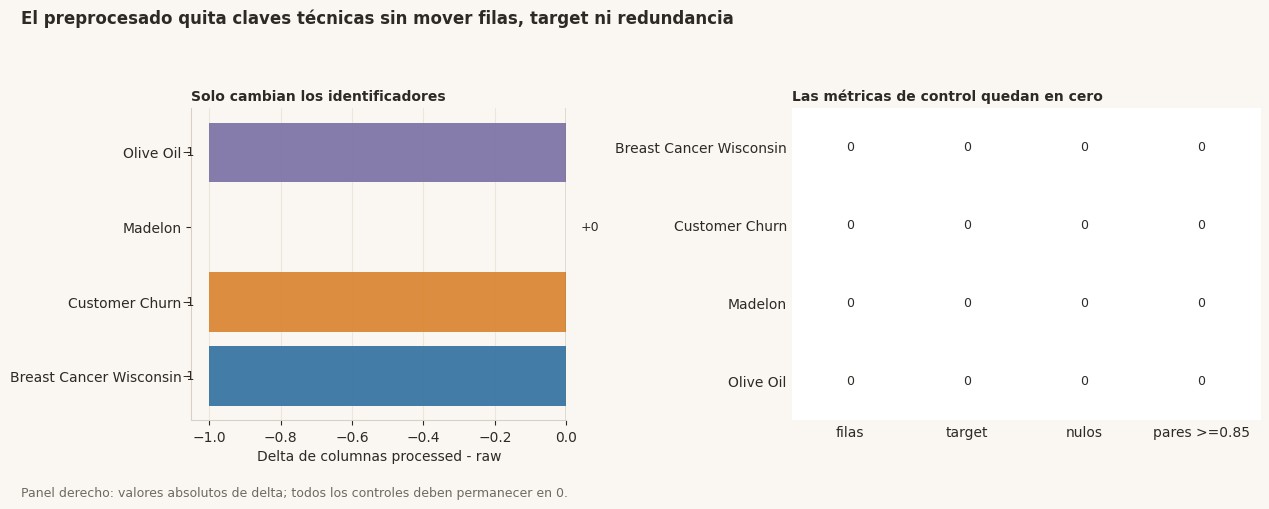

In [92]:
impact_summary = pd.concat([
    impact_breast_cancer_wisconsin,
    impact_customer_churn,
    impact_madelon,
    impact_olive_oil,
], ignore_index=True)

target_shift_summary = pd.concat([
    target_shift_breast_cancer_wisconsin,
    target_shift_customer_churn,
    target_shift_madelon,
    target_shift_olive_oil,
], ignore_index=True)

distribution_shift = pd.concat([
    distribution_shift_breast_cancer_wisconsin,
    distribution_shift_customer_churn,
    distribution_shift_madelon,
    distribution_shift_olive_oil,
], ignore_index=True)

correlation_shift = pd.concat([
    correlation_shift_breast_cancer_wisconsin,
    correlation_shift_customer_churn,
    correlation_shift_madelon,
    correlation_shift_olive_oil,
], ignore_index=True)

guardar_tabla(impact_summary, "fase2_impacto_estructura.csv")
guardar_tabla(target_shift_summary, "fase2_target_shift.csv")
guardar_tabla(distribution_shift, "fase2_distribution_shift.csv")
guardar_tabla(correlation_shift, "fase2_correlation_shift.csv")

mostrar_tabla(impact_summary, "Impacto estructural comparativo")
mostrar_tabla(correlation_shift, "Correlación alta comparativa")
graficar_impacto_preprocesado(impact_summary, correlation_shift)


La comparación final confirma que el impacto estadístico es nulo en las magnitudes que podrían contaminar la evaluación: `delta_filas` es 0 en los cuatro datasets, `target_total_variation` es 0.0000 y `nulos_processed` es 0. La estructura de redundancia fuerte tampoco cambia: 29 pares Spearman >=0.85 en `breast_cancer_wisconsin`, 0 en `customer_churn`, 12 en `madelon` y 2 en `olive_oil`, siempre con `delta_pares` igual a 0.


## 2.14 Guardado y Recarga de Datasets Procesados

Se guardan los datasets procesados como CSV y se recargan desde disco para verificar dimensiones, presencia del target, ausencia de nulos y columnas duplicadas. El criterio de lectura es binario: cada archivo debe conservar su forma procesada, mantener `target`, sumar 0 nulos y no crear nombres repetidos.


In [93]:
def guardar_dataset_procesado(nombre_dataset, datos_dataset):
    output_path = PROCESSED_DATA_DIR / f"{nombre_dataset}_processed.csv"
    datos_dataset.to_csv(output_path, index=False)
    return output_path


def resumir_recarga(nombre_dataset, output_path):
    reloaded_dataset = pd.read_csv(output_path)
    target_name = processed_targets[nombre_dataset]
    return {
        "dataset": nombre_dataset,
        "ruta": str(output_path.relative_to(PROJECT_ROOT)),
        "filas": reloaded_dataset.shape[0],
        "columnas": reloaded_dataset.shape[1],
        "target_presente": target_name in reloaded_dataset.columns,
        "nulos": int(reloaded_dataset.isna().sum().sum()),
        "columnas_duplicadas": int(reloaded_dataset.columns.duplicated().sum()),
        "recarga_correcta": reloaded_dataset.shape == processed_datasets[nombre_dataset].shape,
    }


### Guardado y Recarga: `breast_cancer_wisconsin`


In [94]:
path_breast_cancer_wisconsin = guardar_dataset_procesado("breast_cancer_wisconsin", processed_breast_cancer_wisconsin)
reload_breast_cancer_wisconsin = pd.DataFrame([resumir_recarga("breast_cancer_wisconsin", path_breast_cancer_wisconsin)])

mostrar_tabla(reload_breast_cancer_wisconsin, "Recarga - Breast Cancer Wisconsin")


**Recarga - Breast Cancer Wisconsin** - se muestran las primeras 1 filas de 1.

,Dataset,Ruta,Filas,Columnas,Target presente,Nulos,columnas_duplicadas,recarga_correcta
0,breast_cancer_wisconsin,data/processed/breast_cancer_wisconsin_processed.csv,569,31,True,0,0,True


La recarga mantiene 569 filas, 31 columnas y target presente. El archivo queda preparado para las fases posteriores.


### Guardado y Recarga: `customer_churn`


In [95]:
path_customer_churn = guardar_dataset_procesado("customer_churn", processed_customer_churn)
reload_customer_churn = pd.DataFrame([resumir_recarga("customer_churn", path_customer_churn)])

mostrar_tabla(reload_customer_churn, "Recarga - Customer Churn")


**Recarga - Customer Churn** - se muestran las primeras 1 filas de 1.

,Dataset,Ruta,Filas,Columnas,Target presente,Nulos,columnas_duplicadas,recarga_correcta
0,customer_churn,data/processed/customer_churn_processed.csv,440832,11,True,0,0,True


La recarga confirma que las 440832 filas se guardan sin introducir nulos ni columnas duplicadas.


### Guardado y Recarga: `madelon`


In [96]:
path_madelon = guardar_dataset_procesado("madelon", processed_madelon)
reload_madelon = pd.DataFrame([resumir_recarga("madelon", path_madelon)])

mostrar_tabla(reload_madelon, "Recarga - Madelon")


**Recarga - Madelon** - se muestran las primeras 1 filas de 1.

,Dataset,Ruta,Filas,Columnas,Target presente,Nulos,columnas_duplicadas,recarga_correcta
0,madelon,data/processed/madelon_processed.csv,2000,501,True,0,0,True


La recarga conserva las 501 columnas procesadas: 500 predictoras y target codificado.


### Guardado y Recarga: `olive_oil`


In [97]:
path_olive_oil = guardar_dataset_procesado("olive_oil", processed_olive_oil)
reload_olive_oil = pd.DataFrame([resumir_recarga("olive_oil", path_olive_oil)])

mostrar_tabla(reload_olive_oil, "Recarga - Olive Oil")


**Recarga - Olive Oil** - se muestran las primeras 1 filas de 1.

,Dataset,Ruta,Filas,Columnas,Target presente,Nulos,columnas_duplicadas,recarga_correcta
0,olive_oil,data/processed/olive_oil_processed.csv,572,11,True,0,0,True


La recarga mantiene 572 filas, 11 columnas y el target codificado. Las variables composicionales no reciben modificaciones adicionales.


### Resumen Comparativo de Recarga


In [98]:
reload_summary = pd.concat([
    reload_breast_cancer_wisconsin,
    reload_customer_churn,
    reload_madelon,
    reload_olive_oil,
], ignore_index=True)

guardar_tabla(reload_summary, "fase2_recarga_datasets.csv")
mostrar_tabla(reload_summary, "Recarga de datasets procesados")


**Recarga de datasets procesados** - se muestran las primeras 4 filas de 4.

,Dataset,Ruta,Filas,Columnas,Target presente,Nulos,columnas_duplicadas,recarga_correcta
0,breast_cancer_wisconsin,data/processed/breast_cancer_wisconsin_processed.csv,569,31,True,0,0,True
1,customer_churn,data/processed/customer_churn_processed.csv,440832,11,True,0,0,True
2,madelon,data/processed/madelon_processed.csv,2000,501,True,0,0,True
3,olive_oil,data/processed/olive_oil_processed.csv,572,11,True,0,0,True


La recarga valida los cuatro CSV procesados: 569x31 en `breast_cancer_wisconsin`, 440832x11 en `customer_churn`, 2000x501 en `madelon` y 572x11 en `olive_oil`. En todos los archivos `target_presente` es verdadero, los nulos son 0, las columnas duplicadas son 0 y `recarga_correcta` queda en verdadero. La Fase 3 parte así de CSV recargables, no de objetos vivos en memoria.


## 2.15 Conclusiones y Consideraciones Para la Fase 3

La Fase 2 queda limitada a transformaciones estructurales verificables y cierra con un informe reproducible de tablas, figuras y CSV procesados. Se han normalizado nombres, eliminado identificadores claros, codificado el target y guardado datasets recargables; el criterio de cierre es que ninguna operación estadística haya sido ajustada sobre el conjunto completo.

Para Fase 3 se deben mantener estas condiciones:

- Los encoders de predictoras, imputadores y escaladores se ajustarán solo con particiones de entrenamiento.
- Las variables con baja cardinalidad, outliers, correlaciones altas o asociación fuerte no se eliminan aquí; se revisarán dentro del protocolo de modelado y selección.
- Las variables señaladas por Fase 1 como revisión estadística deben tratarse como hipótesis de trabajo, no como conclusiones automáticas.
- `olive_oil` queda identificado como dos problemas supervisados: `area` con 3 clases y `target` con 9 clases.
- `madelon` debe leerse desde su naturaleza de benchmark sintético: muchas variables son probes irrelevantes por diseño, no errores que haya que limpiar en Fase 2.
- Cualquier reducción de dimensionalidad o selección de características pertenece a fases posteriores, no a la limpieza estructural de Fase 2.


In [99]:
summary_lines = [
    "# Resultados de la Fase 2 - Preprocesado Estructural",
    "",
    "La Fase 2 aplica únicamente transformaciones estructurales verificables: renombrado, exclusión de identificadores, codificación del target y guardado de datasets procesados.",
    "",
    "No se imputan nulos, no se eliminan outliers, no se eliminan variables por baja cardinalidad y no se ajustan encoders ni escaladores globales.",
    "",
    "Los umbrales de cardinalidad/dominancia/correlación se documentan como alertas heurísticas, con referencias a caret, scikit-learn y la ficha UCI/PDF de Madelon cuando procede.",
    "",
    "Tablas principales:",
]

for table_path in sorted(PHASE2_TABLES_DIR.glob("fase2_*.csv")):
    summary_lines.append(f"- `{table_path.relative_to(PROJECT_ROOT)}`")

summary_lines.extend(["", "Figuras:"])
for figure_path in sorted(list(PHASE2_FIGURES_DIR.rglob("fase2_*.png")) + list(PHASE2_FIGURES_DIR.rglob("fase2_*.pdf"))):
    summary_lines.append(f"- `{figure_path.relative_to(PROJECT_ROOT)}`")

summary_lines.extend(["", "Datasets procesados:"])
for dataset_name in DATASET_ORDER:
    summary_lines.append(f"- `data/processed/{dataset_name}_processed.csv`")

summary_path = PHASE2_REPORTS_DIR / "fase2_resumen_para_memoria.md"
summary_path.write_text("\n".join(summary_lines), encoding="utf-8")
print(summary_path.relative_to(PROJECT_ROOT))


results/reports/02_preprocessing/fase2_resumen_para_memoria.md


El resumen para memoria queda escrito en `results/reports/02_preprocessing/fase2_resumen_para_memoria.md`. Ese archivo enumera 21 tablas CSV, 28 ficheros de figura si se cuentan PNG y PDF, y 4 datasets procesados, de modo que la trazabilidad de Fase 2 puede revisarse sin depender del estado de memoria del notebook.
